
# 03 — Cruzamento das métricas automáticas com a avaliação humana — versão revisada

Este notebook constrói o **dataset estatístico final** para analisar a associação entre a avaliação humana e as métricas automáticas.

## Estrutura esperada do experimento

- **5 modelos**
- **3 técnicas** por modelo:
  - zero-shot
  - one-shot
  - few-shot
- **4 famílias principais de arquivos de métricas**:
  - Manhattan
  - METEOR
  - BERTScore
  - NLI

Portanto:

\[
5 \times 3 \times 4 = 60\ arquivos\ CSV
\]

Cada arquivo de uma condição `modelo × técnica` deve possuir, idealmente:

- 259 casos;
- 10 execuções por caso;
- 2.590 `generation_id` únicos.

## Entradas

```text
avaliacao_humana_consolidada.json

metricas/
    metricas_manhattan_....csv
    metricas_meteor_....csv
    metricas_bertscore_....csv
    metricas_nli_....csv
    ...
```

Todos os CSVs podem ficar juntos na mesma pasta.

## Como o notebook evita misturar arquivos

O notebook **não usa a ordem das linhas** e não depende do nome do arquivo para fazer o cruzamento.

Para cada CSV ele:

1. identifica a família da métrica pelas colunas;
2. lê `modelo` e `tecnica` do próprio conteúdo;
3. valida que o arquivo contém apenas um modelo e uma técnica;
4. valida `generation_id`;
5. monta um inventário `família × modelo × técnica`;
6. detecta combinações duplicadas;
7. detecta combinações ausentes;
8. compara os conjuntos de `generation_id` entre as quatro famílias da mesma condição;
9. filtra somente os `generation_id` que foram avaliados pelo humano;
10. cruza pela chave exata `generation_id`.

Assim, a linha da execução 7 nunca será confundida com a execução 1, 2, 3 etc.

## Métricas principais usadas na correlação

Por padrão:

- Manhattan → `distancia_manhattan`
- METEOR → `meteor_score`
- BERTScore → `bertscore_f1`
- NLI → `nli_score`

Os componentes de BERTScore e NLI podem ser habilitados como análises secundárias.

## Análises estatísticas

O notebook executa:

- cobertura das métricas;
- estatística descritiva;
- Shapiro–Wilk;
- histogramas;
- Q-Q plots;
- outliers por IQR;
- diagnóstico de linearidade;
- Pearson;
- Spearman;
- recomendação por par;
- IC95% por bootstrap;
- correção de Holm;
- análise por pares disponíveis;
- análise de sensibilidade por casos completos.


In [ ]:

from pathlib import Path
from collections import Counter
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats


## 1. Configurações

In [ ]:

# ============================================================
# ARQUIVOS E PASTAS
# ============================================================

ARQUIVO_AVALIACAO = Path("avaliacao_humana_consolidada.json")
PASTA_METRICAS = Path("metricas")

PASTA_SAIDA = Path("resultados_correlacao")
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)


# ============================================================
# DESENHO EXPERIMENTAL ESPERADO
# ============================================================

QUANTIDADE_MODELOS_ESPERADA = 5
QUANTIDADE_TECNICAS_ESPERADA = 3

TECNICAS_ESPERADAS = {
    "zero-shot",
    "one-shot",
    "few-shot"
}

FAMILIAS_OBRIGATORIAS = {
    "manhattan",
    "meteor",
    "bertscore",
    "nli"
}

TOTAL_CASOS_ESPERADO_POR_ARQUIVO = 259
EXECUCOES_ESPERADAS_POR_CASO = 10

TOTAL_LINHAS_ESPERADO_POR_ARQUIVO = (
    TOTAL_CASOS_ESPERADO_POR_ARQUIVO
    * EXECUCOES_ESPERADAS_POR_CASO
)

TOTAL_ARQUIVOS_ESPERADO = (
    QUANTIDADE_MODELOS_ESPERADA
    * QUANTIDADE_TECNICAS_ESPERADA
    * len(FAMILIAS_OBRIGATORIAS)
)


# ============================================================
# CONTROLE DAS VALIDAÇÕES
# ============================================================

# True = interrompe a execução se faltar qualquer um dos 60 arquivos.
# Durante testes parciais, pode ser alterado para False.
EXIGIR_CONJUNTO_COMPLETO_60_ARQUIVOS = True

# True = exige 2.590 linhas e IDs únicos por arquivo.
EXIGIR_2590_REGISTROS_POR_ARQUIVO = True

# True = exige que, para a mesma combinação modelo+técnica,
# Manhattan, METEOR, BERTScore e NLI tenham exatamente
# o mesmo conjunto de generation_id.
EXIGIR_MESMOS_IDS_ENTRE_FAMILIAS = True


# ============================================================
# VARIÁVEIS HUMANAS
# ============================================================

# A correlação utiliza exclusivamente a nota final humana.
# Estrutura, semântica e detalhes servem apenas para compor
# a nota final no Notebook 2 e não entram nas análises estatísticas.
VARIAVEIS_HUMANAS = [
    "nota_final"
]


# ============================================================
# MÉTRICAS PRINCIPAIS
# ============================================================

# Estas quatro são as métricas principais da análise.
METRICAS_PRINCIPAIS = [
    "manhattan",
    "meteor",
    "bertscore_f1",
    "nli_score"
]

# Se True, também correlaciona componentes auxiliares,
# aumentando o número de testes estatísticos.
ANALISAR_COMPONENTES_SECUNDARIOS = False


# ============================================================
# PARÂMETROS ESTATÍSTICOS
# ============================================================

ALPHA = 0.05

# 5000 é adequado para análise final.
# Pode aumentar para 10000 se desejar.
N_BOOTSTRAP = 5000

# Bootstrap específico para comparar diretamente as correlações
# entre as métricas. Como existem apenas 6 comparações entre
# as 4 métricas principais, usamos 10.000 reamostragens.
N_BOOTSTRAP_COMPARACAO = 10000

SEED_BOOTSTRAP = 20260827

# Se o modelo quadrático melhorar o R² em mais de 0.05
# sobre o linear, sinalizamos possível não linearidade.
LIMIAR_DELTA_R2_NAO_LINEAR = 0.05

GERAR_GRAFICOS_TODOS_CRITERIOS = False


## 2. Configuração das famílias e colunas

In [ ]:

# ============================================================
# COMO IDENTIFICAR A FAMÍLIA DO ARQUIVO
# ============================================================
#
# A família é identificada pelas colunas do CSV, não pelo nome
# do arquivo.
# ============================================================

FAMILIA_CONFIG = {
    "manhattan": {
        "assinatura": {
            "distancia_manhattan"
        }
    },

    "meteor": {
        "assinatura": {
            "meteor_score"
        }
    },

    "bertscore": {
        "assinatura": {
            "bertscore_precision",
            "bertscore_recall",
            "bertscore_f1"
        }
    },

    "nli": {
        "assinatura": {
            "nli_score",
            "entailment_mean",
            "neutral_mean",
            "contradiction_mean"
        }
    }
}


# ============================================================
# MÉTRICAS NUMÉRICAS QUE PODEM SER EXTRAÍDAS
# ============================================================
#
# principal=True:
#   entra na análise padrão.
#
# principal=False:
#   entra somente se ANALISAR_COMPONENTES_SECUNDARIOS=True.
#
# orientacao:
#   +1 = quanto maior, melhor
#   -1 = quanto menor, melhor
# ============================================================

METRICAS_CONFIG = {
    "manhattan": {
        "familia": "manhattan",
        "coluna": "distancia_manhattan",
        "orientacao": -1,
        "principal": True
    },

    "meteor": {
        "familia": "meteor",
        "coluna": "meteor_score",
        "orientacao": +1,
        "principal": True
    },

    "bertscore_f1": {
        "familia": "bertscore",
        "coluna": "bertscore_f1",
        "orientacao": +1,
        "principal": True
    },

    "nli_score": {
        "familia": "nli",
        "coluna": "nli_score",
        "orientacao": +1,
        "principal": True
    },

    # --------------------------------------------------------
    # COMPONENTES SECUNDÁRIOS
    # --------------------------------------------------------

    "bertscore_precision": {
        "familia": "bertscore",
        "coluna": "bertscore_precision",
        "orientacao": +1,
        "principal": False
    },

    "bertscore_recall": {
        "familia": "bertscore",
        "coluna": "bertscore_recall",
        "orientacao": +1,
        "principal": False
    },

    "nli_entailment": {
        "familia": "nli",
        "coluna": "entailment_mean",
        "orientacao": +1,
        "principal": False
    },

    "nli_neutral": {
        "familia": "nli",
        "coluna": "neutral_mean",
        "orientacao": -1,
        "principal": False
    },

    "nli_contradiction": {
        "familia": "nli",
        "coluna": "contradiction_mean",
        "orientacao": -1,
        "principal": False
    },

    "nli_contradiction_rate": {
        "familia": "nli",
        "coluna": "contradiction_rate",
        "orientacao": -1,
        "principal": False
    },

    "nli_coverage": {
        "familia": "nli",
        "coluna": "coverage",
        "orientacao": +1,
        "principal": False
    }
}



### Correção importante do NLI

Nesta versão:

```text
nli_score
```

é tratado como a **métrica NLI principal**.

Ele não é confundido com:

```text
entailment_mean
```

Os dois permanecem disponíveis como variáveis diferentes.

Da mesma forma, para BERTScore, a variável principal é:

```text
bertscore_f1
```

e `precision`/`recall` ficam como análises secundárias.


## 3. Funções auxiliares

In [ ]:

def carregar_json(caminho):
    if not caminho.exists():
        raise FileNotFoundError(
            f"Arquivo não encontrado: {caminho.resolve()}"
        )

    with open(caminho, "r", encoding="utf-8") as arquivo:
        return json.load(arquivo)


def ler_csv_robusto(caminho):
    tentativas = [
        {"encoding": "utf-8-sig"},
        {"encoding": "utf-8"},
        {"encoding": "latin1"}
    ]

    ultimo_erro = None

    for opcoes in tentativas:
        try:
            df = pd.read_csv(
                caminho,
                **opcoes
            )

            if len(df.columns) == 1:
                df2 = pd.read_csv(
                    caminho,
                    sep=";",
                    **opcoes
                )

                if len(df2.columns) > 1:
                    df = df2

            return df

        except Exception as erro:
            ultimo_erro = erro

    raise RuntimeError(
        f"Não foi possível ler {caminho}: {ultimo_erro}"
    )


def normalizar_nome_coluna(nome):
    nome = str(nome).strip().lower()

    substituicoes = {
        "á": "a",
        "à": "a",
        "ã": "a",
        "â": "a",
        "é": "e",
        "ê": "e",
        "í": "i",
        "ó": "o",
        "ô": "o",
        "õ": "o",
        "ú": "u",
        "ç": "c"
    }

    for origem, destino in substituicoes.items():
        nome = nome.replace(
            origem,
            destino
        )

    nome = re.sub(
        r"[^a-z0-9]+",
        "_",
        nome
    )

    return nome.strip("_")


def padronizar_colunas(df):
    df = df.copy()

    df.columns = [
        normalizar_nome_coluna(coluna)
        for coluna in df.columns
    ]

    aliases = {
        "modelo": "model",
        "tecnica": "technique",
        "execucao": "execution"
    }

    df = df.rename(
        columns={
            antiga: nova
            for antiga, nova in aliases.items()
            if antiga in df.columns
        }
    )

    return df


def detectar_familia(df):
    colunas = set(
        df.columns
    )

    encontradas = []

    for familia, config in FAMILIA_CONFIG.items():
        if config["assinatura"].issubset(colunas):
            encontradas.append(familia)

    if len(encontradas) == 0:
        return None

    if len(encontradas) > 1:
        raise ValueError(
            f"O CSV corresponde a mais de uma família: {encontradas}"
        )

    return encontradas[0]


def valor_unico_obrigatorio(df, coluna, arquivo):
    if coluna not in df.columns:
        raise ValueError(
            f"{arquivo}: coluna obrigatória ausente: {coluna}"
        )

    valores = (
        df[coluna]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
    )

    if len(valores) != 1:
        raise ValueError(
            f"{arquivo}: esperava exatamente um valor em '{coluna}', "
            f"mas encontrei {len(valores)}: {valores[:10]}"
        )

    return valores[0]


## 4. Carregar a avaliação humana consolidada

In [ ]:

dados_avaliacao = carregar_json(
    ARQUIVO_AVALIACAO
)

if "resultados" not in dados_avaliacao:
    raise ValueError(
        "O JSON consolidado não possui a chave 'resultados'."
    )

df_humano = pd.DataFrame(
    dados_avaliacao["resultados"]
)

colunas_obrigatorias = [
    "avaliacao_id",
    "case_id",
    "model",
    "technique",
    "execution",
    "generation_id",
    "estrutura",
    "semantica",
    "detalhes",
    "nota_final"
]

faltantes = [
    coluna
    for coluna in colunas_obrigatorias
    if coluna not in df_humano.columns
]

if faltantes:
    raise ValueError(
        f"Colunas ausentes na avaliação humana: {faltantes}"
    )

if df_humano["generation_id"].isna().any():
    raise ValueError(
        "Existem avaliações sem generation_id."
    )

if df_humano["generation_id"].duplicated().any():
    raise ValueError(
        "Existem generation_id duplicados na avaliação humana."
    )

df_humano["execution"] = pd.to_numeric(
    df_humano["execution"],
    errors="raise"
).astype(int)

IDS_HUMANOS = set(
    df_humano["generation_id"]
)

print(
    f"Avaliações humanas: {len(df_humano)}"
)

print(
    f"Generation IDs únicos: {len(IDS_HUMANOS)}"
)

display(
    df_humano[
        [
            "avaliacao_id",
            "case_id",
            "model",
            "technique",
            "execution",
            "generation_id",
            "nota_final"
        ]
    ].head()
)


Avaliações humanas: 259
Generation IDs únicos: 259


,avaliacao_id,case_id,model,technique,execution,generation_id,nota_final
0,AV_001,TC_559,ibm-granite/granite-4.1-8b,few-shot,6,TC_559__ibm-granite-granite-4.1-8b__few-shot__...,6.6
1,AV_002,TC_7,ibm-granite/granite-4.1-8b,one-shot,7,TC_7__ibm-granite-granite-4.1-8b__one-shot__ex...,7.6
2,AV_003,TC_341,Qwen/Qwen3-8B,one-shot,10,TC_341__qwen-qwen3-8b__one-shot__exec-10,7.6
3,AV_004,TC_848,Qwen/Qwen3-8B,one-shot,7,TC_848__qwen-qwen3-8b__one-shot__exec-07,7.5
4,AV_005,TC_431,ibm-granite/granite-4.1-8b,few-shot,4,TC_431__ibm-granite-granite-4.1-8b__few-shot__...,7.6


## 5. Localizar todos os CSVs

In [ ]:

arquivos_metricas = sorted(
    PASTA_METRICAS.rglob("*.csv")
)

if not arquivos_metricas:
    raise RuntimeError(
        f"Nenhum CSV encontrado em {PASTA_METRICAS.resolve()}"
    )

print(
    f"Arquivos CSV encontrados: {len(arquivos_metricas)}"
)

print(
    f"Arquivos esperados pelo desenho atual: {TOTAL_ARQUIVOS_ESPERADO}"
)


Arquivos CSV encontrados: 60
Arquivos esperados pelo desenho atual: 60


## 6. Construir inventário dos arquivos

In [ ]:

inventario = []
dataframes_por_chave = {}
ids_por_chave = {}

for caminho in arquivos_metricas:

    df = ler_csv_robusto(
        caminho
    )

    df = padronizar_colunas(
        df
    )

    familia = detectar_familia(
        df
    )

    if familia is None:
        raise ValueError(
            f"Não foi possível identificar a família de {caminho.name}. "
            f"Colunas encontradas: {list(df.columns)}"
        )

    modelo = valor_unico_obrigatorio(
        df,
        "model",
        caminho.name
    )

    tecnica = valor_unico_obrigatorio(
        df,
        "technique",
        caminho.name
    )

    if "generation_id" not in df.columns:
        raise ValueError(
            f"{caminho.name}: generation_id ausente."
        )

    if "case_id" not in df.columns:
        raise ValueError(
            f"{caminho.name}: case_id ausente."
        )

    if "execution" not in df.columns:
        raise ValueError(
            f"{caminho.name}: execution/execucao ausente."
        )

    df["execution"] = pd.to_numeric(
        df["execution"],
        errors="raise"
    ).astype(int)

    chave = (
        familia,
        modelo,
        tecnica
    )

    if chave in dataframes_por_chave:
        anterior = dataframes_por_chave[chave]["arquivo"]

        raise ValueError(
            "Combinação duplicada detectada:\n"
            f"  família: {familia}\n"
            f"  modelo: {modelo}\n"
            f"  técnica: {tecnica}\n"
            f"  arquivo 1: {anterior}\n"
            f"  arquivo 2: {caminho.name}"
        )

    n_linhas = len(df)
    n_generation_ids = df["generation_id"].nunique()
    n_casos = df["case_id"].nunique()

    duplicados_generation = int(
        df["generation_id"].duplicated().sum()
    )

    contagem_execucoes = (
        df.groupby("case_id")["execution"]
        .nunique()
    )

    casos_execucao_incompleta = int(
        (contagem_execucoes != EXECUCOES_ESPERADAS_POR_CASO).sum()
    )

    ids = set(
        df["generation_id"]
    )

    inventario.append({
        "familia": familia,
        "modelo": modelo,
        "tecnica": tecnica,
        "arquivo": caminho.name,
        "linhas": n_linhas,
        "casos_unicos": n_casos,
        "generation_ids_unicos": n_generation_ids,
        "generation_ids_duplicados": duplicados_generation,
        "casos_sem_10_execucoes": casos_execucao_incompleta,
        "ids_humanos_encontrados_neste_arquivo": len(
            IDS_HUMANOS & ids
        )
    })

    dataframes_por_chave[chave] = {
        "arquivo": caminho.name,
        "df": df
    }

    ids_por_chave[chave] = ids


df_inventario = pd.DataFrame(
    inventario
).sort_values(
    [
        "modelo",
        "tecnica",
        "familia"
    ]
).reset_index(drop=True)

display(df_inventario)


,familia,modelo,tecnica,arquivo,linhas,casos_unicos,generation_ids_unicos,generation_ids_duplicados,casos_sem_10_execucoes,ids_humanos_encontrados_neste_arquivo
0,bertscore,Qwen/Qwen3-8B,few-shot,metricas_bertscore_qwen-qwen3-8b_few-shot.csv,2590,259,2590,0,0,18
1,manhattan,Qwen/Qwen3-8B,few-shot,metricas_manhattan_qwen-qwen3-8b_few-shot.csv,2590,259,2590,0,0,18
2,meteor,Qwen/Qwen3-8B,few-shot,metricas_meteor_qwen-qwen3-8b_few-shot.csv,2590,259,2590,0,0,18
3,nli,Qwen/Qwen3-8B,few-shot,metricas_nli_passos_bidirecional_qwen-qwen3-8b...,2590,259,2590,0,0,18
4,bertscore,Qwen/Qwen3-8B,one-shot,metricas_bertscore_qwen-qwen3-8b_one-shot.csv,2590,259,2590,0,0,17
5,manhattan,Qwen/Qwen3-8B,one-shot,metricas_manhattan_qwen-qwen3-8b_one-shot.csv,2590,259,2590,0,0,17
6,meteor,Qwen/Qwen3-8B,one-shot,metricas_meteor_qwen-qwen3-8b_one-shot.csv,2590,259,2590,0,0,17
7,nli,Qwen/Qwen3-8B,one-shot,metricas_nli_passos_bidirecional_qwen-qwen3-8b...,2590,259,2590,0,0,17
8,bertscore,Qwen/Qwen3-8B,zero-shot,metricas_bertscore_qwen-qwen3-8b_zero-shot.csv,2590,259,2590,0,0,17
9,manhattan,Qwen/Qwen3-8B,zero-shot,metricas_manhattan_qwen-qwen3-8b_zero-shot.csv,2590,259,2590,0,0,17


## 7. Validar a estrutura 5 modelos × 3 técnicas × 4 famílias

In [ ]:

modelos_encontrados = sorted(
    df_inventario["modelo"].unique()
)

tecnicas_encontradas = set(
    df_inventario["tecnica"].unique()
)

familias_encontradas = set(
    df_inventario["familia"].unique()
)

print("Modelos encontrados:")
for modelo in modelos_encontrados:
    print(" -", modelo)

print(
    "\nTécnicas encontradas:",
    sorted(tecnicas_encontradas)
)

print(
    "\nFamílias encontradas:",
    sorted(familias_encontradas)
)

problemas_estrutura = []

if len(modelos_encontrados) != QUANTIDADE_MODELOS_ESPERADA:
    problemas_estrutura.append(
        f"Esperados {QUANTIDADE_MODELOS_ESPERADA} modelos, "
        f"encontrados {len(modelos_encontrados)}."
    )

if tecnicas_encontradas != TECNICAS_ESPERADAS:
    problemas_estrutura.append(
        f"Técnicas esperadas: {sorted(TECNICAS_ESPERADAS)}; "
        f"encontradas: {sorted(tecnicas_encontradas)}."
    )

if not FAMILIAS_OBRIGATORIAS.issubset(familias_encontradas):
    problemas_estrutura.append(
        f"Famílias obrigatórias ausentes: "
        f"{sorted(FAMILIAS_OBRIGATORIAS - familias_encontradas)}"
    )


# ============================================================
# MATRIZ DE PRESENÇA
# ============================================================

combinacoes_esperadas = []

for modelo in modelos_encontrados:
    for tecnica in sorted(TECNICAS_ESPERADAS):
        for familia in sorted(FAMILIAS_OBRIGATORIAS):
            combinacoes_esperadas.append(
                (familia, modelo, tecnica)
            )

chaves_encontradas = set(
    dataframes_por_chave.keys()
)

combinacoes_ausentes = [
    chave
    for chave in combinacoes_esperadas
    if chave not in chaves_encontradas
]

if combinacoes_ausentes:
    problemas_estrutura.append(
        f"Existem {len(combinacoes_ausentes)} combinações "
        "família × modelo × técnica ausentes."
    )


if len(arquivos_metricas) != TOTAL_ARQUIVOS_ESPERADO:
    problemas_estrutura.append(
        f"Esperados {TOTAL_ARQUIVOS_ESPERADO} CSVs, "
        f"encontrados {len(arquivos_metricas)}."
    )


if combinacoes_ausentes:
    print("\nCOMBINAÇÕES AUSENTES:")

    for familia, modelo, tecnica in combinacoes_ausentes:
        print(
            f" - {familia} | {modelo} | {tecnica}"
        )


if problemas_estrutura:
    print("\nPROBLEMAS ENCONTRADOS:")

    for problema in problemas_estrutura:
        print(" -", problema)

    if EXIGIR_CONJUNTO_COMPLETO_60_ARQUIVOS:
        raise RuntimeError(
            "A estrutura completa de arquivos não foi atendida."
        )
else:
    print(
        "\nEstrutura completa validada: "
        f"{TOTAL_ARQUIVOS_ESPERADO} arquivos."
    )


Modelos encontrados:
 - Qwen/Qwen3-8B
 - google/gemma-4-E4B-it
 - ibm-granite/granite-4.1-8b
 - meta-llama/Meta-Llama-3-8B-Instruct
 - mistralai/Mistral-7B-Instruct-v0.3

Técnicas encontradas: ['few-shot', 'one-shot', 'zero-shot']

Famílias encontradas: ['bertscore', 'manhattan', 'meteor', 'nli']

Estrutura completa validada: 60 arquivos.


## 8. Validar 2.590 registros e 10 execuções por caso

In [ ]:

problemas_conteudo = []

for _, linha in df_inventario.iterrows():

    identificacao = (
        f"{linha['familia']} | "
        f"{linha['modelo']} | "
        f"{linha['tecnica']}"
    )

    if linha["linhas"] != TOTAL_LINHAS_ESPERADO_POR_ARQUIVO:
        problemas_conteudo.append(
            f"{identificacao}: "
            f"{linha['linhas']} linhas; "
            f"esperado {TOTAL_LINHAS_ESPERADO_POR_ARQUIVO}."
        )

    if linha["casos_unicos"] != TOTAL_CASOS_ESPERADO_POR_ARQUIVO:
        problemas_conteudo.append(
            f"{identificacao}: "
            f"{linha['casos_unicos']} casos; "
            f"esperado {TOTAL_CASOS_ESPERADO_POR_ARQUIVO}."
        )

    if linha["generation_ids_unicos"] != TOTAL_LINHAS_ESPERADO_POR_ARQUIVO:
        problemas_conteudo.append(
            f"{identificacao}: "
            f"{linha['generation_ids_unicos']} generation_id únicos; "
            f"esperado {TOTAL_LINHAS_ESPERADO_POR_ARQUIVO}."
        )

    if linha["generation_ids_duplicados"] != 0:
        problemas_conteudo.append(
            f"{identificacao}: "
            f"{linha['generation_ids_duplicados']} generation_id duplicados."
        )

    if linha["casos_sem_10_execucoes"] != 0:
        problemas_conteudo.append(
            f"{identificacao}: "
            f"{linha['casos_sem_10_execucoes']} casos sem 10 execuções."
        )


if problemas_conteudo:
    print("PROBLEMAS DE CONTEÚDO:")

    for problema in problemas_conteudo:
        print(" -", problema)

    if EXIGIR_2590_REGISTROS_POR_ARQUIVO:
        raise RuntimeError(
            "Existem arquivos incompletos ou inconsistentes."
        )

else:
    print(
        "Todos os arquivos possuem a estrutura esperada: "
        "259 casos × 10 execuções = 2.590 registros."
    )


Todos os arquivos possuem a estrutura esperada: 259 casos × 10 execuções = 2.590 registros.


## 9. Conferir se as quatro famílias possuem os mesmos IDs dentro de cada condição

In [ ]:

divergencias_ids = []

for modelo in modelos_encontrados:
    for tecnica in sorted(TECNICAS_ESPERADAS):

        chaves_condicao = [
            (
                familia,
                modelo,
                tecnica
            )
            for familia in sorted(FAMILIAS_OBRIGATORIAS)
            if (
                familia,
                modelo,
                tecnica
            ) in ids_por_chave
        ]

        if len(chaves_condicao) < 2:
            continue

        chave_referencia = chaves_condicao[0]
        ids_referencia = ids_por_chave[
            chave_referencia
        ]

        for chave_atual in chaves_condicao[1:]:
            ids_atual = ids_por_chave[
                chave_atual
            ]

            faltando_no_atual = (
                ids_referencia
                - ids_atual
            )

            extras_no_atual = (
                ids_atual
                - ids_referencia
            )

            if faltando_no_atual or extras_no_atual:
                divergencias_ids.append({
                    "modelo": modelo,
                    "tecnica": tecnica,
                    "familia_referencia": chave_referencia[0],
                    "familia_comparada": chave_atual[0],
                    "faltando_na_comparada": len(faltando_no_atual),
                    "extras_na_comparada": len(extras_no_atual)
                })


df_divergencias_ids = pd.DataFrame(
    divergencias_ids
)

if not df_divergencias_ids.empty:
    display(df_divergencias_ids)

    if EXIGIR_MESMOS_IDS_ENTRE_FAMILIAS:
        raise RuntimeError(
            "As famílias de métricas não possuem o mesmo conjunto "
            "de generation_id dentro de algumas condições."
        )
else:
    print(
        "Validação concluída: dentro de cada modelo × técnica, "
        "as quatro famílias possuem o mesmo conjunto de generation_id."
    )


Validação concluída: dentro de cada modelo × técnica, as quatro famílias possuem o mesmo conjunto de generation_id.


## 10. Filtrar imediatamente somente os 259 IDs avaliados pelo humano

In [ ]:

metricas_long = []
cobertura_por_arquivo = []

for chave, conteudo in dataframes_por_chave.items():

    familia, modelo, tecnica = chave
    arquivo = conteudo["arquivo"]
    df = conteudo["df"]

    df_filtrado = df[
        df["generation_id"].isin(
            IDS_HUMANOS
        )
    ].copy()

    cobertura_por_arquivo.append({
        "familia": familia,
        "modelo": modelo,
        "tecnica": tecnica,
        "arquivo": arquivo,
        "linhas_originais": len(df),
        "linhas_selecionadas_para_avaliacao_humana": len(df_filtrado)
    })

    for nome_metrica, config in METRICAS_CONFIG.items():

        if config["familia"] != familia:
            continue

        if (
            not config["principal"]
            and not ANALISAR_COMPONENTES_SECUNDARIOS
        ):
            continue

        coluna_valor = config["coluna"]

        if coluna_valor not in df_filtrado.columns:
            raise ValueError(
                f"{arquivo}: coluna esperada '{coluna_valor}' "
                f"não foi encontrada para a métrica {nome_metrica}."
            )

        temp = df_filtrado[
            [
                "generation_id",
                "case_id",
                "model",
                "technique",
                "execution",
                coluna_valor
            ]
        ].copy()

        temp = temp.rename(
            columns={
                coluna_valor: "valor"
            }
        )

        temp["metrica"] = nome_metrica
        temp["familia"] = familia
        temp["orientacao"] = config["orientacao"]
        temp["arquivo_origem"] = arquivo

        temp["valor"] = pd.to_numeric(
            temp["valor"],
            errors="coerce"
        )

        metricas_long.append(
            temp
        )


df_cobertura_arquivo = pd.DataFrame(
    cobertura_por_arquivo
)

print(
    "Os arquivos completos foram reduzidos aos registros "
    "efetivamente avaliados pelo humano."
)

display(
    df_cobertura_arquivo
)


Os arquivos completos foram reduzidos aos registros efetivamente avaliados pelo humano.


,familia,modelo,tecnica,arquivo,linhas_originais,linhas_selecionadas_para_avaliacao_humana
0,bertscore,google/gemma-4-E4B-it,few-shot,metricas_bertscore_google-gemma-4-e4b-it_few-s...,2590,17
1,bertscore,google/gemma-4-E4B-it,one-shot,metricas_bertscore_google-gemma-4-e4b-it_one-s...,2590,18
2,bertscore,google/gemma-4-E4B-it,zero-shot,metricas_bertscore_google-gemma-4-e4b-it_zero-...,2590,17
3,bertscore,ibm-granite/granite-4.1-8b,few-shot,metricas_bertscore_ibm-granite-granite-4.1-8b_...,2590,17
4,bertscore,ibm-granite/granite-4.1-8b,one-shot,metricas_bertscore_ibm-granite-granite-4.1-8b_...,2590,17
5,bertscore,ibm-granite/granite-4.1-8b,zero-shot,metricas_bertscore_ibm-granite-granite-4.1-8b_...,2590,17
6,bertscore,meta-llama/Meta-Llama-3-8B-Instruct,few-shot,metricas_bertscore_meta-llama-meta-llama-3-8b-...,2590,17
7,bertscore,meta-llama/Meta-Llama-3-8B-Instruct,one-shot,metricas_bertscore_meta-llama-meta-llama-3-8b-...,2590,17
8,bertscore,meta-llama/Meta-Llama-3-8B-Instruct,zero-shot,metricas_bertscore_meta-llama-meta-llama-3-8b-...,2590,18
9,bertscore,mistralai/Mistral-7B-Instruct-v0.3,few-shot,metricas_bertscore_mistralai-mistral-7b-instru...,2590,17



### Por que filtrar antes de concatenar?

Com 60 arquivos de 2.590 linhas, o conjunto bruto possui até:

\[
60 	imes 2590 = 155.400\ linhas
\]

Mas apenas 259 BDDs foram avaliados pelo humano.

Por isso, cada arquivo é filtrado primeiro pelo conjunto de `generation_id` humanos. Depois os registros selecionados são concatenados.


## 11. Consolidar as métricas selecionadas

In [ ]:

if not metricas_long:
    raise RuntimeError(
        "Nenhuma métrica foi extraída."
    )

df_metricas_long = pd.concat(
    metricas_long,
    ignore_index=True
)

# generation_id deve aparecer no máximo uma vez por métrica
duplicados = (
    df_metricas_long
    .groupby(
        [
            "metrica",
            "generation_id"
        ]
    )
    .size()
    .reset_index(
        name="quantidade"
    )
)

duplicados = duplicados[
    duplicados["quantidade"] > 1
]

if not duplicados.empty:
    display(
        duplicados.head(50)
    )

    raise ValueError(
        "Existem generation_id duplicados dentro da mesma métrica."
    )


metricas_detectadas = sorted(
    df_metricas_long["metrica"].unique()
)

print(
    "Métricas que entrarão na análise:"
)

for metrica in metricas_detectadas:
    quantidade = int(
        (
            df_metricas_long["metrica"]
            == metrica
        ).sum()
    )

    print(
        f" - {metrica}: {quantidade} registros"
    )


Métricas que entrarão na análise:
 - bertscore_f1: 259 registros
 - manhattan: 259 registros
 - meteor: 259 registros
 - nli_score: 259 registros


## 12. Validação redundante de caso, modelo, técnica e execução

In [ ]:

indice_humano = (
    df_humano[
        [
            "generation_id",
            "case_id",
            "model",
            "technique",
            "execution"
        ]
    ]
    .copy()
    .rename(
        columns={
            "case_id": "case_id_humano",
            "model": "model_humano",
            "technique": "technique_humano",
            "execution": "execution_humano"
        }
    )
)

df_validacao = df_metricas_long.merge(
    indice_humano,
    on="generation_id",
    how="inner"
)

inconsistencias = []

for coluna_metrica, coluna_humano in [
    ("case_id", "case_id_humano"),
    ("model", "model_humano"),
    ("technique", "technique_humano"),
    ("execution", "execution_humano")
]:

    esquerda = df_validacao[
        coluna_metrica
    ]

    direita = df_validacao[
        coluna_humano
    ]

    mascara = (
        esquerda.notna()
        & direita.notna()
    )

    if coluna_metrica == "execution":
        e = pd.to_numeric(
            esquerda[mascara],
            errors="coerce"
        )

        d = pd.to_numeric(
            direita[mascara],
            errors="coerce"
        )

    else:
        e = (
            esquerda[mascara]
            .astype(str)
            .str.strip()
        )

        d = (
            direita[mascara]
            .astype(str)
            .str.strip()
        )

    diferente = (
        e != d
    )

    if diferente.any():
        indices = diferente.index[
            diferente
        ]

        inconsistencias.append({
            "campo": coluna_metrica,
            "quantidade": len(indices),
            "exemplos": df_validacao.loc[
                indices,
                "generation_id"
            ].head(10).tolist()
        })


if inconsistencias:
    display(
        pd.DataFrame(
            inconsistencias
        )
    )

    raise RuntimeError(
        "Os metadados das métricas não coincidem com "
        "a avaliação humana."
    )

print(
    "Validação redundante concluída: "
    "case_id, modelo, técnica e execução estão coerentes."
)


Validação redundante concluída: case_id, modelo, técnica e execução estão coerentes.


## 13. Cobertura final por métrica

In [ ]:

registros_cobertura = []
ids_faltantes_por_metrica = {}

for metrica in metricas_detectadas:

    temp = df_metricas_long[
        df_metricas_long["metrica"]
        == metrica
    ]

    ids_metrica = set(
        temp["generation_id"]
    )

    encontrados = (
        IDS_HUMANOS
        & ids_metrica
    )

    faltantes = (
        IDS_HUMANOS
        - ids_metrica
    )

    ids_faltantes_por_metrica[
        metrica
    ] = sorted(
        faltantes
    )

    registros_cobertura.append({
        "metrica": metrica,
        "avaliacoes_humanas": len(IDS_HUMANOS),
        "encontrados": len(encontrados),
        "faltantes": len(faltantes),
        "cobertura_percentual": round(
            100 * len(encontrados)
            / len(IDS_HUMANOS),
            2
        )
    })


df_cobertura = pd.DataFrame(
    registros_cobertura
)

display(
    df_cobertura
)


for metrica, faltantes in ids_faltantes_por_metrica.items():

    if not faltantes:
        continue

    print(
        f"\n{metrica}: {len(faltantes)} IDs humanos ausentes"
    )

    for generation_id in faltantes[:20]:
        print(
            "  ",
            generation_id
        )

    if len(faltantes) > 20:
        print(
            f"  ... e mais {len(faltantes) - 20}"
        )


,metrica,avaliacoes_humanas,encontrados,faltantes,cobertura_percentual
0,bertscore_f1,259,259,0,100.0
1,manhattan,259,259,0,100.0
2,meteor,259,259,0,100.0
3,nli_score,259,259,0,100.0


## 14. Criar o dataset final de correlação

In [ ]:

df_valores_metricas = df_metricas_long[
    [
        "generation_id",
        "metrica",
        "valor"
    ]
].copy()

df_metricas_wide = (
    df_valores_metricas
    .pivot(
        index="generation_id",
        columns="metrica",
        values="valor"
    )
    .reset_index()
)

df_metricas_wide.columns.name = None

df_correlacao = df_humano.merge(
    df_metricas_wide,
    on="generation_id",
    how="left",
    validate="one_to_one"
)

if len(df_correlacao) != len(df_humano):
    raise RuntimeError(
        "O merge alterou a quantidade de avaliações."
    )

print(
    f"Dataset estatístico final: {len(df_correlacao)} linhas"
)

display(
    df_correlacao[
        [
            "avaliacao_id",
            "case_id",
            "model",
            "technique",
            "execution",
            "generation_id",
            "nota_final"
        ]
        + metricas_detectadas
    ].head()
)


Dataset estatístico final: 259 linhas


,avaliacao_id,case_id,model,technique,execution,generation_id,nota_final,bertscore_f1,manhattan,meteor,nli_score
0,AV_001,TC_559,ibm-granite/granite-4.1-8b,few-shot,6,TC_559__ibm-granite-granite-4.1-8b__few-shot__...,6.6,49.624073,35.0,0.82,0.704042
1,AV_002,TC_7,ibm-granite/granite-4.1-8b,one-shot,7,TC_7__ibm-granite-granite-4.1-8b__one-shot__ex...,7.6,49.310936,39.0,0.89,0.666664
2,AV_003,TC_341,Qwen/Qwen3-8B,one-shot,10,TC_341__qwen-qwen3-8b__one-shot__exec-10,7.6,53.715862,28.0,0.87,0.668502
3,AV_004,TC_848,Qwen/Qwen3-8B,one-shot,7,TC_848__qwen-qwen3-8b__one-shot__exec-07,7.5,49.947517,36.0,0.85,0.497842
4,AV_005,TC_431,ibm-granite/granite-4.1-8b,few-shot,4,TC_431__ibm-granite-granite-4.1-8b__few-shot__...,7.6,63.358730,35.0,0.88,0.465526



Cada linha do dataset final corresponde a **um único BDD avaliado**.

Exemplo conceitual:

```text
AV_001
TC_x
modelo X
few-shot
execução 6
generation_id ...exec-06
nota_final
Manhattan da exec-06
METEOR da exec-06
BERTScore F1 da exec-06
NLI score da exec-06
```

Nenhuma métrica é obtida por posição da linha.


## 15. Estatística descritiva

In [ ]:

variaveis_analise = (
    VARIAVEIS_HUMANAS
    + metricas_detectadas
)

descritiva = []

for variavel in variaveis_analise:

    serie = pd.to_numeric(
        df_correlacao[variavel],
        errors="coerce"
    ).dropna()

    if serie.empty:
        continue

    descritiva.append({
        "variavel": variavel,
        "n": int(len(serie)),
        "media": float(serie.mean()),
        "mediana": float(serie.median()),
        "desvio_padrao": float(serie.std(ddof=1)),
        "minimo": float(serie.min()),
        "q1": float(serie.quantile(0.25)),
        "q3": float(serie.quantile(0.75)),
        "maximo": float(serie.max())
    })

df_descritiva = pd.DataFrame(
    descritiva
)

display(
    df_descritiva
)


,variavel,n,media,mediana,desvio_padrao,minimo,q1,q3,maximo
0,nota_final,259,6.927413,7.100000,0.860267,3.800000,6.600000,7.500000,8.500000
1,bertscore_f1,259,47.026091,46.701370,11.046819,-1.023932,40.704214,54.387125,75.249374
2,manhattan,259,38.474903,36.000000,16.354904,14.000000,30.500000,43.000000,162.000000
3,meteor,259,0.781699,0.810000,0.101837,0.430000,0.745000,0.850000,0.930000
4,nli_score,259,0.655587,0.667026,0.149883,0.223949,0.557535,0.754644,0.998839


## 16. Shapiro–Wilk — variável por variável

In [ ]:

def teste_shapiro(serie, alpha=ALPHA):

    # Aceita pandas Series, listas e numpy.ndarray.
    # A conversão para Series garante acesso a dropna()
    # independentemente do tipo recebido.
    serie = pd.Series(
        serie
    )

    serie = pd.to_numeric(
        serie,
        errors="coerce"
    )

    serie = (
        serie
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(serie) < 3:
        return {
            "n": len(serie),
            "W": np.nan,
            "p_value": np.nan,
            "rejeita_normalidade": None
        }

    # Shapiro-Wilk exige alguma variabilidade.
    # Se todos os valores forem iguais, a distribuição
    # não pode ser avaliada adequadamente pelo teste.
    if serie.nunique() < 2:
        return {
            "n": len(serie),
            "W": np.nan,
            "p_value": np.nan,
            "rejeita_normalidade": None
        }

    with warnings.catch_warnings():
        warnings.simplefilter(
            "ignore"
        )

        resultado = stats.shapiro(
            serie.to_numpy(dtype=float)
        )

    return {
        "n": len(serie),
        "W": float(resultado.statistic),
        "p_value": float(resultado.pvalue),
        "rejeita_normalidade": bool(
            resultado.pvalue < alpha
        )
    }


normalidade = []

for variavel in variaveis_analise:

    resultado = teste_shapiro(
        df_correlacao[variavel]
    )

    normalidade.append({
        "variavel": variavel,
        **resultado
    })


df_normalidade = pd.DataFrame(
    normalidade
)

display(
    df_normalidade
)


,variavel,n,W,p_value,rejeita_normalidade
0,nota_final,259,0.928806,7.960003e-10,True
1,bertscore_f1,259,0.961375,2.017950e-06,True
2,manhattan,259,0.705350,4.587774e-21,True
3,meteor,259,0.892382,1.300773e-12,True
4,nli_score,259,0.986948,1.872494e-02,True



O teste acima verifica somente:

- `nota_final` da avaliação humana;
- cada métrica automática.

Quando houver dados ausentes em uma métrica, a etapa de correlação também recalculará o Shapiro no **subconjunto pareado exato** utilizado naquela correlação.


## 17. Histogramas

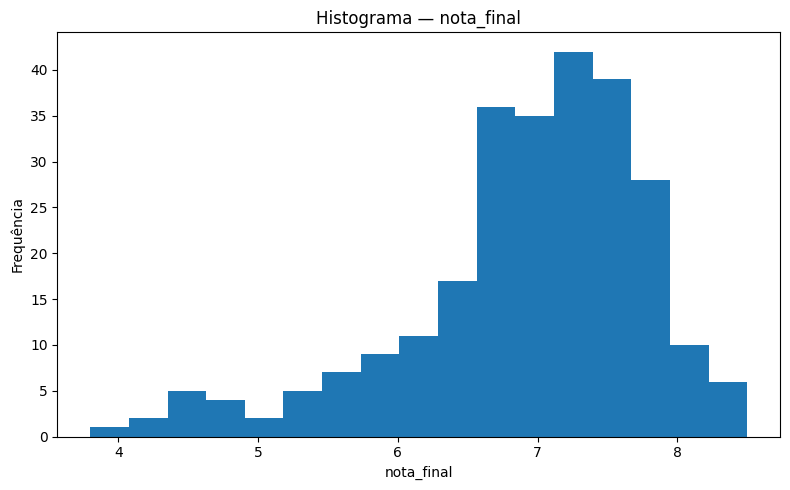

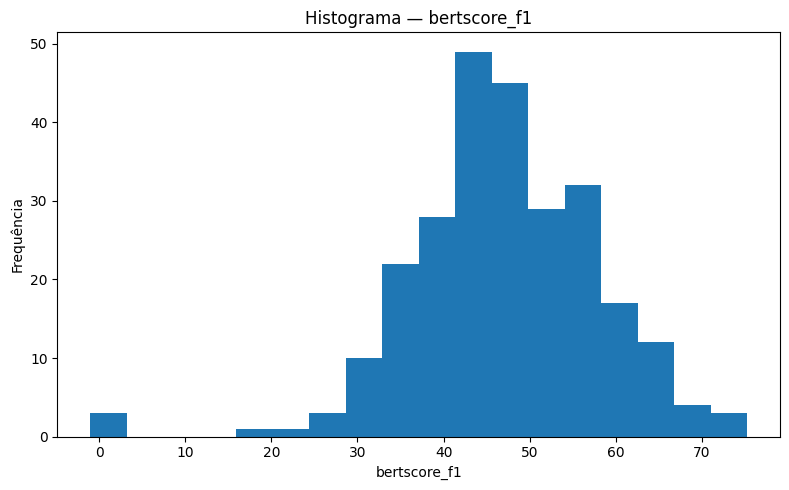

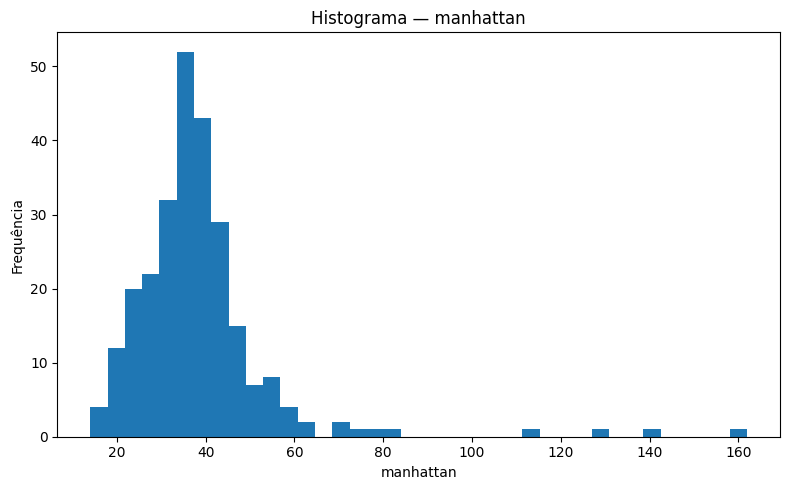

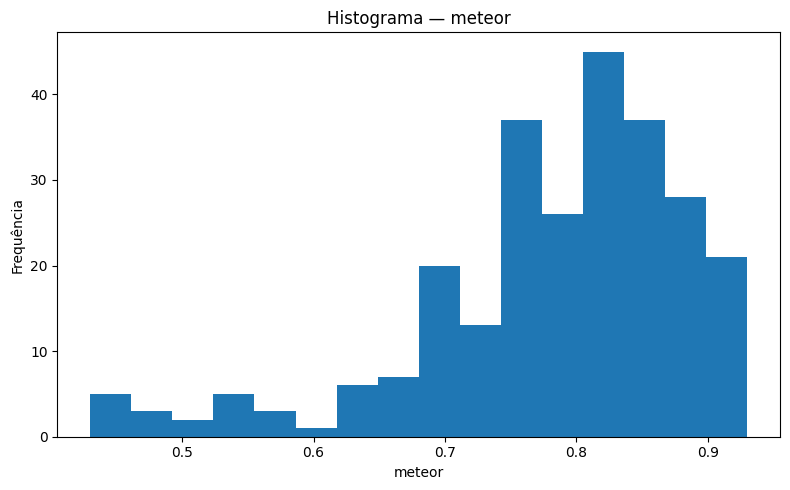

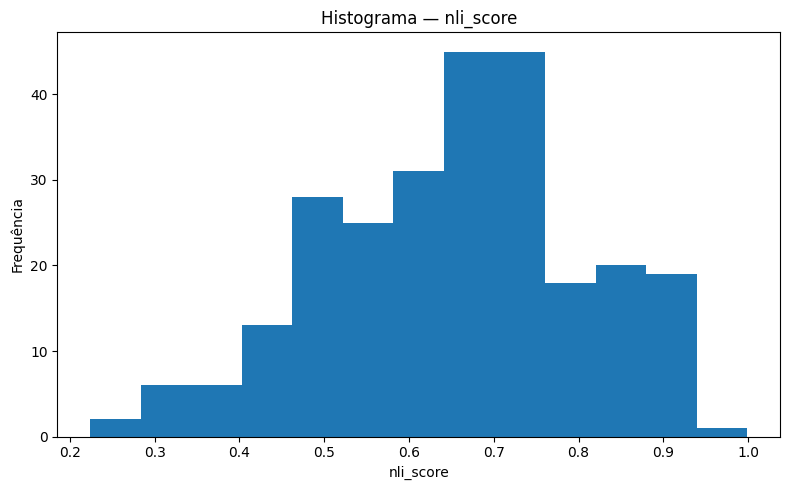

In [ ]:

for variavel in variaveis_analise:

    serie = pd.to_numeric(
        df_correlacao[variavel],
        errors="coerce"
    ).dropna()

    if serie.empty:
        continue

    plt.figure(
        figsize=(8, 5)
    )

    plt.hist(
        serie,
        bins="auto"
    )

    plt.title(
        f"Histograma — {variavel}"
    )

    plt.xlabel(
        variavel
    )

    plt.ylabel(
        "Frequência"
    )

    plt.tight_layout()
    plt.show()


## 18. Q-Q plots

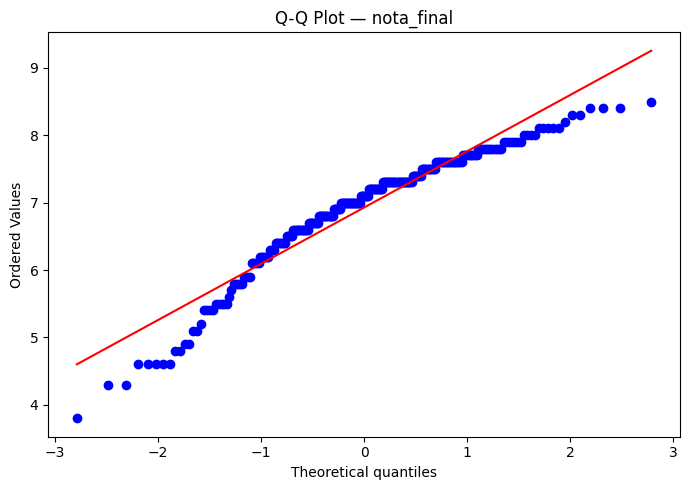

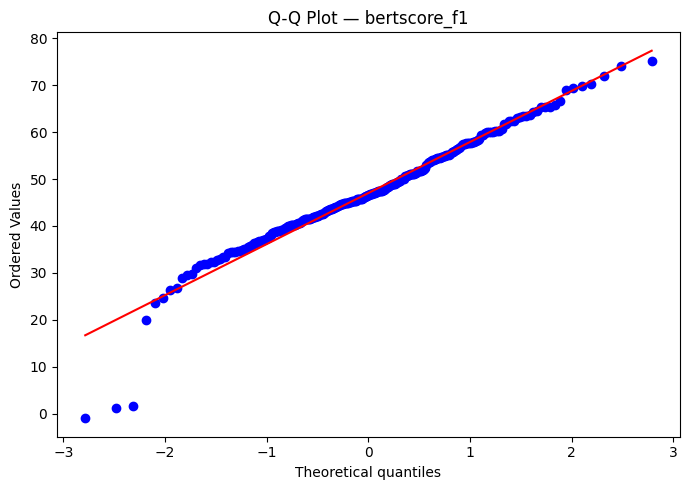

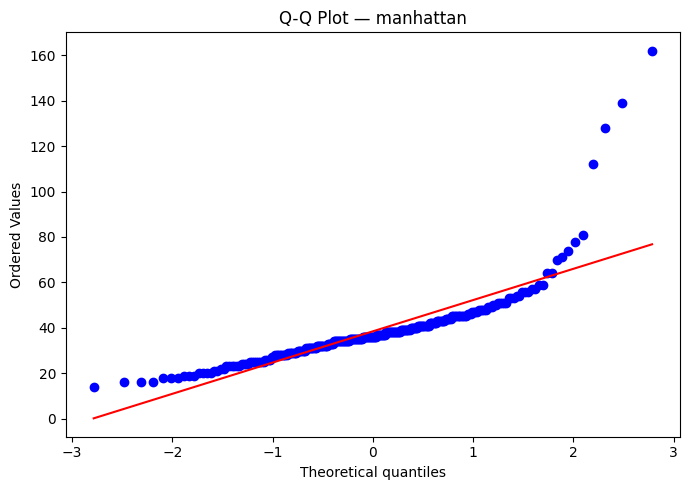

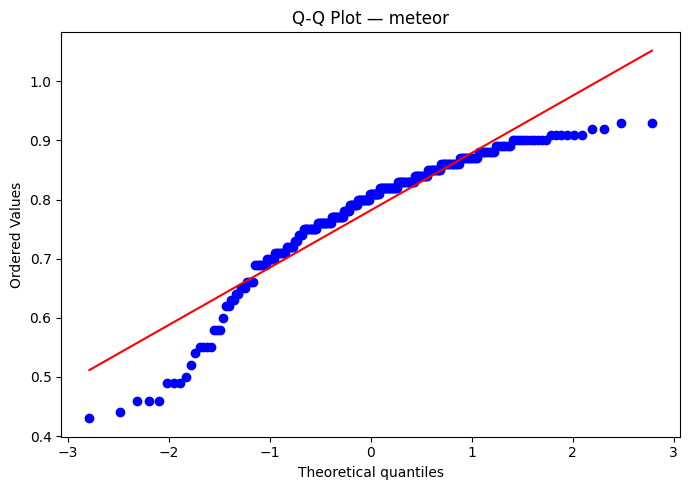

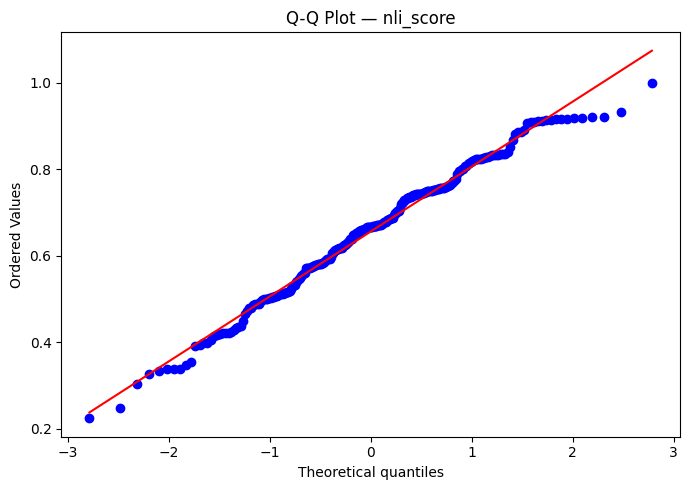

In [ ]:

for variavel in variaveis_analise:

    serie = pd.to_numeric(
        df_correlacao[variavel],
        errors="coerce"
    ).dropna()

    if len(serie) < 3:
        continue

    plt.figure(
        figsize=(7, 5)
    )

    stats.probplot(
        serie,
        dist="norm",
        plot=plt
    )

    plt.title(
        f"Q-Q Plot — {variavel}"
    )

    plt.tight_layout()
    plt.show()


## 19. Funções estatísticas

In [ ]:

def preparar_par(df, coluna_x, coluna_y):

    temp = df[
        [
            coluna_x,
            coluna_y
        ]
    ].copy()

    temp[coluna_x] = pd.to_numeric(
        temp[coluna_x],
        errors="coerce"
    )

    temp[coluna_y] = pd.to_numeric(
        temp[coluna_y],
        errors="coerce"
    )

    return (
        temp
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
    )


def diagnostico_outliers(serie):

    serie = pd.Series(
        serie,
        dtype=float
    ).dropna()

    if serie.empty:
        return {
            "outliers": 0,
            "outliers_extremos": 0,
            "percentual_outliers": np.nan
        }

    q1 = serie.quantile(
        0.25
    )

    q3 = serie.quantile(
        0.75
    )

    iqr = q3 - q1

    if iqr == 0:
        return {
            "outliers": 0,
            "outliers_extremos": 0,
            "percentual_outliers": 0.0
        }

    outliers = (
        (serie < q1 - 1.5 * iqr)
        | (serie > q3 + 1.5 * iqr)
    )

    extremos = (
        (serie < q1 - 3.0 * iqr)
        | (serie > q3 + 3.0 * iqr)
    )

    return {
        "outliers": int(outliers.sum()),
        "outliers_extremos": int(extremos.sum()),
        "percentual_outliers": float(
            100 * outliers.sum() / len(serie)
        )
    }


def calcular_r2(y_real, y_pred):

    y_real = np.asarray(
        y_real,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    ss_res = np.sum(
        (y_real - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_real - np.mean(y_real)) ** 2
    )

    if ss_tot == 0:
        return np.nan

    return (
        1 - ss_res / ss_tot
    )


def diagnostico_linearidade(x, y):

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    if (
        len(x) < 5
        or len(np.unique(x)) < 3
    ):
        return {
            "r2_linear": np.nan,
            "r2_quadratico": np.nan,
            "delta_r2": np.nan,
            "aproximadamente_linear": None
        }

    try:
        linear = np.polyfit(
            x,
            y,
            deg=1
        )

        y_linear = np.polyval(
            linear,
            x
        )

        r2_linear = calcular_r2(
            y,
            y_linear
        )

        quadratico = np.polyfit(
            x,
            y,
            deg=2
        )

        y_quad = np.polyval(
            quadratico,
            x
        )

        r2_quad = calcular_r2(
            y,
            y_quad
        )

        delta = (
            r2_quad
            - r2_linear
        )

        return {
            "r2_linear": float(r2_linear),
            "r2_quadratico": float(r2_quad),
            "delta_r2": float(delta),
            "aproximadamente_linear": bool(
                delta <= LIMIAR_DELTA_R2_NAO_LINEAR
            )
        }

    except Exception:

        return {
            "r2_linear": np.nan,
            "r2_quadratico": np.nan,
            "delta_r2": np.nan,
            "aproximadamente_linear": None
        }


def correlacao_segura(x, y, metodo):

    if len(x) < 3:
        return np.nan, np.nan

    if (
        np.std(x) == 0
        or np.std(y) == 0
    ):
        return np.nan, np.nan

    if metodo == "pearson":
        resultado = stats.pearsonr(
            x,
            y
        )

    elif metodo == "spearman":
        resultado = stats.spearmanr(
            x,
            y
        )

    else:
        raise ValueError(
            metodo
        )

    return (
        float(resultado.statistic),
        float(resultado.pvalue)
    )


def bootstrap_correlacao(
    x,
    y,
    metodo,
    n_bootstrap=N_BOOTSTRAP,
    seed=SEED_BOOTSTRAP
):

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    n = len(x)

    if n < 4:
        return np.nan, np.nan

    rng = np.random.default_rng(
        seed
    )

    valores = []

    for _ in range(n_bootstrap):

        indices = rng.integers(
            0,
            n,
            size=n
        )

        xb = x[
            indices
        ]

        yb = y[
            indices
        ]

        if (
            np.std(xb) == 0
            or np.std(yb) == 0
        ):
            continue

        if metodo == "pearson":
            valor = stats.pearsonr(
                xb,
                yb
            ).statistic

        else:
            valor = stats.spearmanr(
                xb,
                yb
            ).statistic

        if np.isfinite(valor):
            valores.append(
                float(valor)
            )

    if len(valores) < 100:
        return np.nan, np.nan

    return tuple(
        float(x)
        for x in np.percentile(
            valores,
            [
                2.5,
                97.5
            ]
        )
    )


def holm_bonferroni(p_values):

    p_values = np.asarray(
        p_values,
        dtype=float
    )

    saida = np.full(
        len(p_values),
        np.nan
    )

    validos = np.where(
        np.isfinite(p_values)
    )[0]

    if len(validos) == 0:
        return saida

    p = p_values[
        validos
    ]

    ordem = np.argsort(
        p
    )

    ordenados = p[
        ordem
    ]

    m = len(ordenados)

    ajustados = np.empty(
        m
    )

    acumulado = 0.0

    for i, valor in enumerate(ordenados):

        ajustado = min(
            1.0,
            (m - i) * valor
        )

        acumulado = max(
            acumulado,
            ajustado
        )

        ajustados[i] = acumulado

    reverso = np.empty(
        m
    )

    reverso[
        ordem
    ] = ajustados

    saida[
        validos
    ] = reverso

    return saida


## 20. Correlação e decisão por par

In [ ]:

mapa_orientacao = {
    nome: config["orientacao"]
    for nome, config in METRICAS_CONFIG.items()
}


resultados = []

for variavel_humana in VARIAVEIS_HUMANAS:

    for metrica in metricas_detectadas:

        par = preparar_par(
            df_correlacao,
            variavel_humana,
            metrica
        )

        if len(par) < 3:
            continue

        x = par[
            variavel_humana
        ].to_numpy(
            dtype=float
        )

        y = par[
            metrica
        ].to_numpy(
            dtype=float
        )

        # ----------------------------------------------------
        # NORMALIDADE NO EXATO SUBCONJUNTO PAREADO
        # ----------------------------------------------------

        shapiro_humana = teste_shapiro(
            x
        )

        shapiro_metrica = teste_shapiro(
            y
        )

        ambas_normais = (
            shapiro_humana["p_value"] >= ALPHA
            and shapiro_metrica["p_value"] >= ALPHA
        )

        # ----------------------------------------------------
        # OUTLIERS
        # ----------------------------------------------------

        out_h = diagnostico_outliers(
            x
        )

        out_m = diagnostico_outliers(
            y
        )

        total_extremos = (
            out_h["outliers_extremos"]
            + out_m["outliers_extremos"]
        )

        # ----------------------------------------------------
        # LINEARIDADE
        # ----------------------------------------------------

        linearidade = diagnostico_linearidade(
            x,
            y
        )

        # ----------------------------------------------------
        # CORRELAÇÕES
        # ----------------------------------------------------

        pearson_r, pearson_p = correlacao_segura(
            x,
            y,
            "pearson"
        )

        spearman_rho, spearman_p = correlacao_segura(
            x,
            y,
            "spearman"
        )

        pearson_inf, pearson_sup = bootstrap_correlacao(
            x,
            y,
            "pearson"
        )

        spearman_inf, spearman_sup = bootstrap_correlacao(
            x,
            y,
            "spearman"
        )

        # ----------------------------------------------------
        # RECOMENDAÇÃO
        # ----------------------------------------------------

        if (
            ambas_normais
            and total_extremos == 0
            and linearidade["aproximadamente_linear"] is True
        ):

            metodo = "Pearson"

            motivo = (
                "ambas as variáveis não rejeitam normalidade; "
                "sem outliers extremos; "
                "relação aproximadamente linear"
            )

        else:

            metodo = "Spearman"

            motivos = []

            if not ambas_normais:
                motivos.append(
                    "normalidade não atendida por pelo menos uma variável"
                )

            if total_extremos > 0:
                motivos.append(
                    "presença de outliers extremos"
                )

            if linearidade["aproximadamente_linear"] is False:
                motivos.append(
                    "indício de não linearidade"
                )

            if linearidade["aproximadamente_linear"] is None:
                motivos.append(
                    "linearidade não determinada automaticamente"
                )

            motivo = "; ".join(
                motivos
            )

        orientacao = mapa_orientacao.get(
            metrica,
            +1
        )

        resultados.append({
            "variavel_humana": variavel_humana,
            "metrica": metrica,
            "n": len(par),

            "shapiro_humana_W": shapiro_humana["W"],
            "shapiro_humana_p": shapiro_humana["p_value"],

            "shapiro_metrica_W": shapiro_metrica["W"],
            "shapiro_metrica_p": shapiro_metrica["p_value"],

            "ambas_nao_rejeitam_normalidade": ambas_normais,

            "outliers_humana": out_h["outliers"],
            "outliers_metrica": out_m["outliers"],
            "outliers_extremos_total": total_extremos,

            "r2_linear": linearidade["r2_linear"],
            "r2_quadratico": linearidade["r2_quadratico"],
            "delta_r2": linearidade["delta_r2"],
            "aproximadamente_linear": linearidade["aproximadamente_linear"],

            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "pearson_ic95_inf": pearson_inf,
            "pearson_ic95_sup": pearson_sup,

            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p,
            "spearman_ic95_inf": spearman_inf,
            "spearman_ic95_sup": spearman_sup,

            "orientacao_metrica": orientacao,

            "pearson_orientado": (
                pearson_r * orientacao
                if np.isfinite(pearson_r)
                else np.nan
            ),

            "spearman_orientado": (
                spearman_rho * orientacao
                if np.isfinite(spearman_rho)
                else np.nan
            ),

            "metodo_recomendado": metodo,
            "motivo_recomendacao": motivo
        })


df_correlacoes = pd.DataFrame(
    resultados
)

display(
    df_correlacoes
)


,variavel_humana,metrica,n,shapiro_humana_W,shapiro_humana_p,shapiro_metrica_W,shapiro_metrica_p,ambas_nao_rejeitam_normalidade,outliers_humana,outliers_metrica,...,pearson_ic95_sup,spearman_rho,spearman_p,spearman_ic95_inf,spearman_ic95_sup,orientacao_metrica,pearson_orientado,spearman_orientado,metodo_recomendado,motivo_recomendacao
0,nota_final,bertscore_f1,259,0.928806,7.960003e-10,0.961375,2.017950e-06,False,15,5,...,0.719463,0.623141,2.945419e-29,0.534183,0.701133,1,0.645129,0.623141,Spearman,normalidade não atendida por pelo menos uma va...
1,nota_final,manhattan,259,0.928806,7.960003e-10,0.705350,4.587774e-21,False,15,11,...,-0.459749,-0.489254,5.403428e-17,-0.589109,-0.381868,-1,0.568126,0.489254,Spearman,normalidade não atendida por pelo menos uma va...
2,nota_final,meteor,259,0.928806,7.960003e-10,0.892382,1.300773e-12,False,15,18,...,0.435388,0.282261,3.935247e-06,0.162912,0.395249,1,0.315581,0.282261,Spearman,normalidade não atendida por pelo menos uma va...
3,nota_final,nli_score,259,0.928806,7.960003e-10,0.986948,1.872494e-02,False,15,2,...,0.296142,0.175438,4.629562e-03,0.054562,0.296037,1,0.176418,0.175438,Spearman,normalidade não atendida por pelo menos uma va...


## 21. Correção de Holm

In [ ]:

if not df_correlacoes.empty:

    df_correlacoes[
        "pearson_p_holm"
    ] = holm_bonferroni(
        df_correlacoes[
            "pearson_p"
        ].to_numpy()
    )

    df_correlacoes[
        "spearman_p_holm"
    ] = holm_bonferroni(
        df_correlacoes[
            "spearman_p"
        ].to_numpy()
    )


display(
    df_correlacoes[
        [
            "variavel_humana",
            "metrica",
            "n",
            "pearson_r",
            "pearson_p",
            "pearson_p_holm",
            "spearman_rho",
            "spearman_p",
            "spearman_p_holm",
            "metodo_recomendado"
        ]
    ]
)


,variavel_humana,metrica,n,pearson_r,pearson_p,pearson_p_holm,spearman_rho,spearman_p,spearman_p_holm,metodo_recomendado
0,nota_final,bertscore_f1,259,0.645129,7.084045e-32,2.833618e-31,0.623141,2.945419e-29,1.178168e-28,Spearman
1,nota_final,manhattan,259,-0.568126,1.543360e-23,4.630081e-23,-0.489254,5.403428e-17,1.621028e-16,Spearman
2,nota_final,meteor,259,0.315581,2.132644e-07,4.265287e-07,0.282261,3.935247e-06,7.870493e-06,Spearman
3,nota_final,nli_score,259,0.176418,4.402069e-03,4.402069e-03,0.175438,4.629562e-03,4.629562e-03,Spearman


## 22. Tabela principal — nota final × métricas

In [ ]:

df_correlacao_nota_final = (
    df_correlacoes[
        df_correlacoes[
            "variavel_humana"
        ] == "nota_final"
    ]
    .copy()
    .sort_values(
        "spearman_orientado",
        ascending=False
    )
)


display(
    df_correlacao_nota_final[
        [
            "metrica",
            "n",

            "shapiro_humana_p",
            "shapiro_metrica_p",

            "outliers_extremos_total",
            "aproximadamente_linear",

            "pearson_r",
            "pearson_ic95_inf",
            "pearson_ic95_sup",
            "pearson_p_holm",

            "spearman_rho",
            "spearman_ic95_inf",
            "spearman_ic95_sup",
            "spearman_p_holm",

            "pearson_orientado",
            "spearman_orientado",

            "metodo_recomendado",
            "motivo_recomendacao"
        ]
    ]
)


,metrica,n,shapiro_humana_p,shapiro_metrica_p,outliers_extremos_total,aproximadamente_linear,pearson_r,pearson_ic95_inf,pearson_ic95_sup,pearson_p_holm,spearman_rho,spearman_ic95_inf,spearman_ic95_sup,spearman_p_holm,pearson_orientado,spearman_orientado,metodo_recomendado,motivo_recomendacao
0,bertscore_f1,259,7.960003e-10,2.017950e-06,2,True,0.645129,0.557525,0.719463,2.833618e-31,0.623141,0.534183,0.701133,1.178168e-28,0.645129,0.623141,Spearman,normalidade não atendida por pelo menos uma va...
1,manhattan,259,7.960003e-10,4.587774e-21,6,True,-0.568126,-0.659752,-0.459749,4.630081e-23,-0.489254,-0.589109,-0.381868,1.621028e-16,0.568126,0.489254,Spearman,normalidade não atendida por pelo menos uma va...
2,meteor,259,7.960003e-10,1.300773e-12,2,True,0.315581,0.191457,0.435388,4.265287e-07,0.282261,0.162912,0.395249,7.870493e-06,0.315581,0.282261,Spearman,normalidade não atendida por pelo menos uma va...
3,nli_score,259,7.960003e-10,1.872494e-02,1,True,0.176418,0.057789,0.296142,4.402069e-03,0.175438,0.054562,0.296037,4.629562e-03,0.176418,0.175438,Spearman,normalidade não atendida por pelo menos uma va...


## 23. Resumo Spearman — nota final × métricas

In [ ]:
tabela_spearman = (
    df_correlacoes[
        df_correlacoes["variavel_humana"] == "nota_final"
    ][
        [
            "metrica",
            "n",
            "spearman_rho",
            "spearman_orientado",
            "spearman_p",
            "spearman_p_holm",
            "metodo_recomendado"
        ]
    ]
    .copy()
    .sort_values(
        "spearman_orientado",
        ascending=False
    )
)

display(
    tabela_spearman
)


,metrica,n,spearman_rho,spearman_orientado,spearman_p,spearman_p_holm,metodo_recomendado
0,bertscore_f1,259,0.623141,0.623141,2.945419e-29,1.178168e-28,Spearman
1,manhattan,259,-0.489254,0.489254,5.403428e-17,1.621028e-16,Spearman
2,meteor,259,0.282261,0.282261,3.935247e-06,7.870493e-06,Spearman
3,nli_score,259,0.175438,0.175438,4.629562e-03,4.629562e-03,Spearman


## 24. Gráficos de dispersão

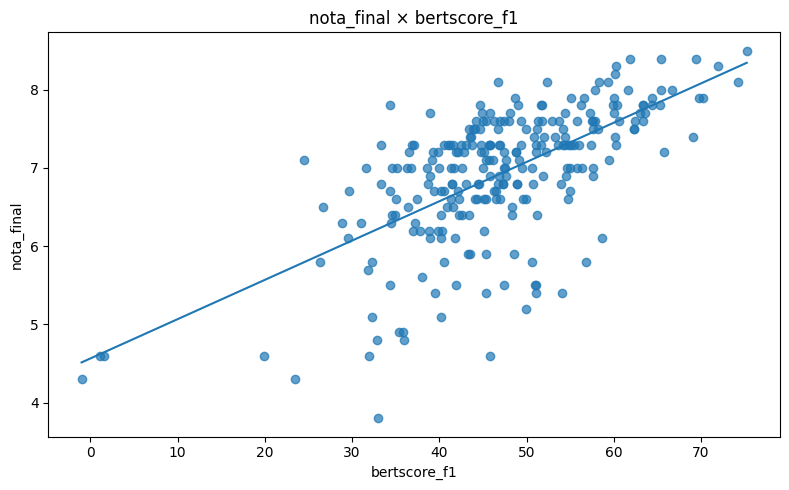

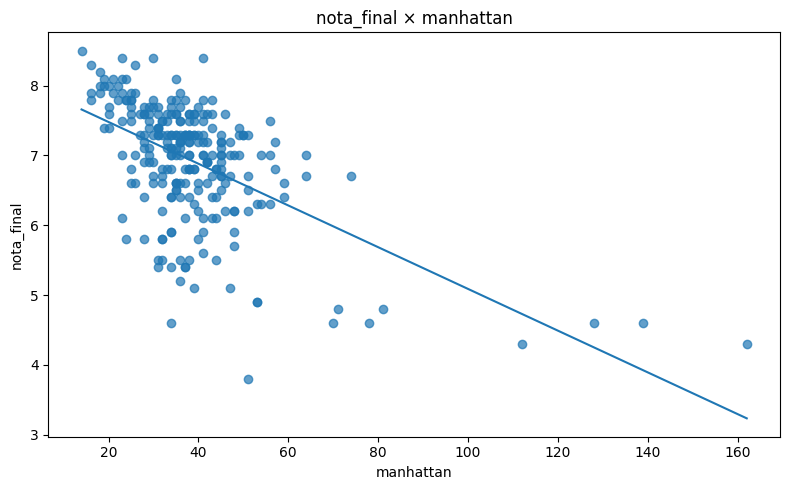

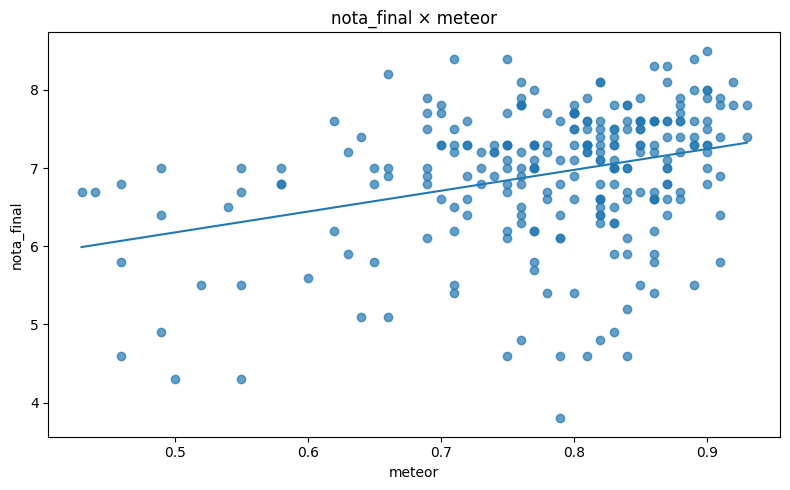

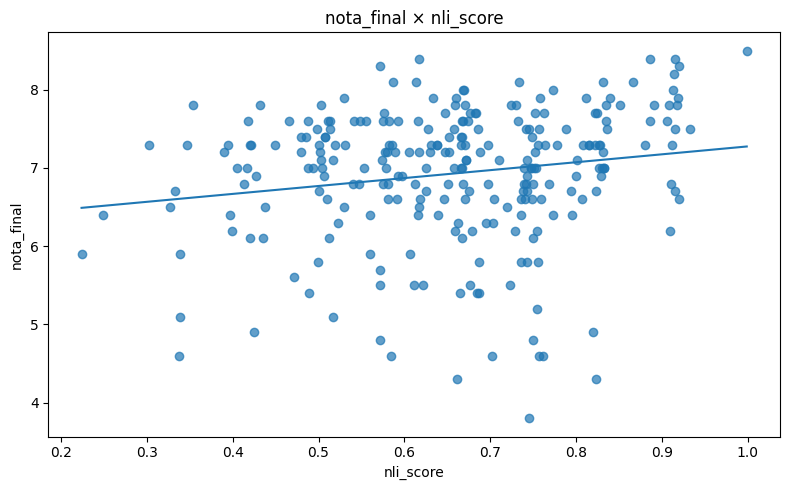

In [ ]:

criterios_grafico = (
    VARIAVEIS_HUMANAS
    if GERAR_GRAFICOS_TODOS_CRITERIOS
    else ["nota_final"]
)

for variavel_humana in criterios_grafico:

    for metrica in metricas_detectadas:

        par = preparar_par(
            df_correlacao,
            variavel_humana,
            metrica
        )

        if len(par) < 3:
            continue

        x = par[
            metrica
        ].to_numpy(
            dtype=float
        )

        y = par[
            variavel_humana
        ].to_numpy(
            dtype=float
        )

        plt.figure(
            figsize=(8, 5)
        )

        plt.scatter(
            x,
            y,
            alpha=0.7
        )

        if (
            len(np.unique(x)) >= 2
            and np.std(x) > 0
        ):

            coef = np.polyfit(
                x,
                y,
                deg=1
            )

            ordem = np.argsort(
                x
            )

            plt.plot(
                x[ordem],
                np.polyval(
                    coef,
                    x[ordem]
                )
            )

        plt.xlabel(
            metrica
        )

        plt.ylabel(
            variavel_humana
        )

        plt.title(
            f"{variavel_humana} × {metrica}"
        )

        plt.tight_layout()
        plt.show()


## 25. Análise de sensibilidade — casos completos

In [ ]:

df_casos_completos = (
    df_correlacao
    .dropna(
        subset=metricas_detectadas
    )
    .copy()
)

print(
    f"Casos completos em todas as métricas: "
    f"{len(df_casos_completos)} / {len(df_correlacao)}"
)


resultados_completos = []

for variavel_humana in VARIAVEIS_HUMANAS:

    for metrica in metricas_detectadas:

        par = preparar_par(
            df_casos_completos,
            variavel_humana,
            metrica
        )

        if len(par) < 3:
            continue

        x = par[
            variavel_humana
        ].to_numpy(
            dtype=float
        )

        y = par[
            metrica
        ].to_numpy(
            dtype=float
        )

        pearson_r, pearson_p = correlacao_segura(
            x,
            y,
            "pearson"
        )

        spearman_rho, spearman_p = correlacao_segura(
            x,
            y,
            "spearman"
        )

        orientacao = mapa_orientacao.get(
            metrica,
            +1
        )

        resultados_completos.append({
            "variavel_humana": variavel_humana,
            "metrica": metrica,
            "n": len(par),
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p,
            "pearson_orientado": (
                pearson_r * orientacao
                if np.isfinite(pearson_r)
                else np.nan
            ),
            "spearman_orientado": (
                spearman_rho * orientacao
                if np.isfinite(spearman_rho)
                else np.nan
            )
        })


df_correlacoes_completos = pd.DataFrame(
    resultados_completos
)

if not df_correlacoes_completos.empty:

    df_correlacoes_completos[
        "pearson_p_holm"
    ] = holm_bonferroni(
        df_correlacoes_completos[
            "pearson_p"
        ].to_numpy()
    )

    df_correlacoes_completos[
        "spearman_p_holm"
    ] = holm_bonferroni(
        df_correlacoes_completos[
            "spearman_p"
        ].to_numpy()
    )


display(
    df_correlacoes_completos
)


Casos completos em todas as métricas: 259 / 259


,variavel_humana,metrica,n,pearson_r,pearson_p,spearman_rho,spearman_p,pearson_orientado,spearman_orientado,pearson_p_holm,spearman_p_holm
0,nota_final,bertscore_f1,259,0.645129,7.084045e-32,0.623141,2.945419e-29,0.645129,0.623141,2.833618e-31,1.178168e-28
1,nota_final,manhattan,259,-0.568126,1.543360e-23,-0.489254,5.403428e-17,0.568126,0.489254,4.630081e-23,1.621028e-16
2,nota_final,meteor,259,0.315581,2.132644e-07,0.282261,3.935247e-06,0.315581,0.282261,4.265287e-07,7.870493e-06
3,nota_final,nli_score,259,0.176418,4.402069e-03,0.175438,4.629562e-03,0.176418,0.175438,4.402069e-03,4.629562e-03



## 26. Comparação estatística direta entre as métricas

O ranking pelo valor observado de Spearman mostra **qual métrica apresentou a maior associação observada** com a `nota_final`.

Entretanto, uma correlação de `0.38` não é automaticamente estatisticamente superior a uma correlação de `0.24`.

Por isso, esta etapa compara diretamente as métricas em pares usando **bootstrap pareado**.

Para cada par de métricas:

1. selecionam-se somente os BDDs que possuem `nota_final` e ambas as métricas;
2. as mesmas linhas são reamostradas para as duas métricas;
3. calcula-se o Spearman orientado de cada métrica;
4. calcula-se:

\[
\Delta \rho =
\rho_{\text{métrica A, orientado}}
-
\rho_{\text{métrica B, orientado}}
\]

5. o processo é repetido `N_BOOTSTRAP_COMPARACAO` vezes;
6. obtém-se o IC95% da diferença;
7. calcula-se um p-valor bootstrap bilateral;
8. aplica-se correção de Holm às comparações múltiplas.

### Interpretação

Se o IC95% de \(\Delta\rho\) **não incluir zero** e o `p_holm < 0.05`, há evidência de diferença estatisticamente sustentada entre as correlações.

Se o intervalo incluir zero, a métrica com maior coeficiente continua sendo a de **maior correlação observada**, mas a diferença entre as duas é considerada inconclusiva.


In [ ]:

from itertools import combinations


def spearman_orientado_seguro(nota, metrica, orientacao):
    nota = np.asarray(nota, dtype=float)
    metrica = np.asarray(metrica, dtype=float)

    if len(nota) < 3:
        return np.nan

    if np.std(nota) == 0 or np.std(metrica) == 0:
        return np.nan

    rho = stats.spearmanr(
        nota,
        metrica
    ).statistic

    if not np.isfinite(rho):
        return np.nan

    return float(
        rho * orientacao
    )


def comparar_duas_metricas_bootstrap(
    df,
    metrica_a,
    metrica_b,
    orientacao_a,
    orientacao_b,
    n_bootstrap=N_BOOTSTRAP_COMPARACAO,
    seed=SEED_BOOTSTRAP
):
    # Mesmo subconjunto para as duas métricas
    temp = df[
        [
            "nota_final",
            metrica_a,
            metrica_b
        ]
    ].copy()

    for coluna in [
        "nota_final",
        metrica_a,
        metrica_b
    ]:
        temp[coluna] = pd.to_numeric(
            temp[coluna],
            errors="coerce"
        )

    temp = (
        temp
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
    )

    n = len(temp)

    if n < 4:
        return {
            "n": n,
            "rho_a_orientado": np.nan,
            "rho_b_orientado": np.nan,
            "delta_observado": np.nan,
            "ic95_inf": np.nan,
            "ic95_sup": np.nan,
            "p_bootstrap": np.nan,
            "n_bootstrap_validos": 0
        }

    nota = temp[
        "nota_final"
    ].to_numpy(
        dtype=float
    )

    a = temp[
        metrica_a
    ].to_numpy(
        dtype=float
    )

    b = temp[
        metrica_b
    ].to_numpy(
        dtype=float
    )

    rho_a = spearman_orientado_seguro(
        nota,
        a,
        orientacao_a
    )

    rho_b = spearman_orientado_seguro(
        nota,
        b,
        orientacao_b
    )

    delta_observado = (
        rho_a - rho_b
        if np.isfinite(rho_a)
        and np.isfinite(rho_b)
        else np.nan
    )

    rng = np.random.default_rng(
        seed
    )

    deltas = []

    for _ in range(n_bootstrap):
        indices = rng.integers(
            0,
            n,
            size=n
        )

        nota_b = nota[
            indices
        ]

        a_b = a[
            indices
        ]

        b_b = b[
            indices
        ]

        rho_a_b = spearman_orientado_seguro(
            nota_b,
            a_b,
            orientacao_a
        )

        rho_b_b = spearman_orientado_seguro(
            nota_b,
            b_b,
            orientacao_b
        )

        if (
            np.isfinite(rho_a_b)
            and np.isfinite(rho_b_b)
        ):
            deltas.append(
                rho_a_b - rho_b_b
            )

    deltas = np.asarray(
        deltas,
        dtype=float
    )

    if len(deltas) < 100:
        return {
            "n": n,
            "rho_a_orientado": rho_a,
            "rho_b_orientado": rho_b,
            "delta_observado": delta_observado,
            "ic95_inf": np.nan,
            "ic95_sup": np.nan,
            "p_bootstrap": np.nan,
            "n_bootstrap_validos": len(deltas)
        }

    ic95_inf, ic95_sup = np.percentile(
        deltas,
        [
            2.5,
            97.5
        ]
    )

    # p-valor bootstrap bilateral em torno de zero
    prop_menor_igual_zero = np.mean(
        deltas <= 0
    )

    prop_maior_igual_zero = np.mean(
        deltas >= 0
    )

    p_bootstrap = min(
        1.0,
        2.0
        * min(
            prop_menor_igual_zero,
            prop_maior_igual_zero
        )
    )

    return {
        "n": n,
        "rho_a_orientado": rho_a,
        "rho_b_orientado": rho_b,
        "delta_observado": float(
            delta_observado
        ),
        "ic95_inf": float(
            ic95_inf
        ),
        "ic95_sup": float(
            ic95_sup
        ),
        "p_bootstrap": float(
            p_bootstrap
        ),
        "n_bootstrap_validos": int(
            len(deltas)
        )
    }


# ============================================================
# SOMENTE AS MÉTRICAS PRINCIPAIS ENTRAM NA DISPUTA
# PELA "MELHOR MÉTRICA"
# ============================================================

metricas_ranking = [
    metrica
    for metrica in METRICAS_PRINCIPAIS
    if metrica in df_correlacao.columns
]

if len(metricas_ranking) < 2:
    raise RuntimeError(
        "São necessárias pelo menos duas métricas principais "
        "para realizar a comparação estatística direta."
    )


comparacoes_metricas = []

for metrica_a, metrica_b in combinations(
    metricas_ranking,
    2
):
    resultado = comparar_duas_metricas_bootstrap(
        df=df_correlacao,
        metrica_a=metrica_a,
        metrica_b=metrica_b,
        orientacao_a=mapa_orientacao.get(
            metrica_a,
            +1
        ),
        orientacao_b=mapa_orientacao.get(
            metrica_b,
            +1
        )
    )

    comparacoes_metricas.append({
        "metrica_a": metrica_a,
        "metrica_b": metrica_b,
        **resultado
    })


df_comparacoes_metricas = pd.DataFrame(
    comparacoes_metricas
)

if not df_comparacoes_metricas.empty:
    df_comparacoes_metricas[
        "p_holm"
    ] = holm_bonferroni(
        df_comparacoes_metricas[
            "p_bootstrap"
        ].to_numpy()
    )

    df_comparacoes_metricas[
        "ic95_exclui_zero"
    ] = (
        (
            df_comparacoes_metricas[
                "ic95_inf"
            ] > 0
        )
        |
        (
            df_comparacoes_metricas[
                "ic95_sup"
            ] < 0
        )
    )

    df_comparacoes_metricas[
        "diferenca_significativa"
    ] = (
        df_comparacoes_metricas[
            "ic95_exclui_zero"
        ]
        &
        (
            df_comparacoes_metricas[
                "p_holm"
            ] < ALPHA
        )
    )

    def interpretar_comparacao(linha):
        if not linha[
            "diferenca_significativa"
        ]:
            return (
                "diferença inconclusiva"
            )

        if linha[
            "delta_observado"
        ] > 0:
            return (
                f"{linha['metrica_a']} > "
                f"{linha['metrica_b']}"
            )

        if linha[
            "delta_observado"
        ] < 0:
            return (
                f"{linha['metrica_b']} > "
                f"{linha['metrica_a']}"
            )

        return (
            "sem diferença observada"
        )

    df_comparacoes_metricas[
        "interpretacao"
    ] = df_comparacoes_metricas.apply(
        interpretar_comparacao,
        axis=1
    )


display(
    df_comparacoes_metricas[
        [
            "metrica_a",
            "metrica_b",
            "n",
            "rho_a_orientado",
            "rho_b_orientado",
            "delta_observado",
            "ic95_inf",
            "ic95_sup",
            "p_bootstrap",
            "p_holm",
            "diferenca_significativa",
            "interpretacao"
        ]
    ]
)


,metrica_a,metrica_b,n,rho_a_orientado,rho_b_orientado,delta_observado,ic95_inf,ic95_sup,p_bootstrap,p_holm,diferenca_significativa,interpretacao
0,manhattan,meteor,259,0.489254,0.282261,0.206993,0.068483,0.349425,0.0028,0.0056,True,manhattan > meteor
1,manhattan,bertscore_f1,259,0.489254,0.623141,-0.133887,-0.218921,-0.048182,0.0014,0.0042,True,bertscore_f1 > manhattan
2,manhattan,nli_score,259,0.489254,0.175438,0.313816,0.176501,0.451176,0.0000,0.0000,True,manhattan > nli_score
3,meteor,bertscore_f1,259,0.282261,0.623141,-0.340879,-0.471232,-0.214039,0.0000,0.0000,True,bertscore_f1 > meteor
4,meteor,nli_score,259,0.282261,0.175438,0.106824,-0.052274,0.264423,0.1922,0.1922,False,diferença inconclusiva
5,bertscore_f1,nli_score,259,0.623141,0.175438,0.447703,0.308933,0.581385,0.0000,0.0000,True,bertscore_f1 > nli_score



## 27. Ranking das métricas

O ranking principal utiliza o **Spearman orientado** com a `nota_final`.

A primeira colocada é a métrica com a maior associação observada.

A comparação bootstrap da seção anterior informa se essa vantagem é também estatisticamente sustentada.


In [ ]:

# ============================================================
# RANKING OBSERVADO
# ============================================================

df_ranking_metricas = (
    df_correlacao_nota_final[
        df_correlacao_nota_final[
            "metrica"
        ].isin(
            metricas_ranking
        )
    ][
        [
            "metrica",
            "n",
            "spearman_rho",
            "spearman_orientado",
            "spearman_ic95_inf",
            "spearman_ic95_sup",
            "spearman_p",
            "spearman_p_holm",
            "pearson_r",
            "pearson_orientado",
            "metodo_recomendado"
        ]
    ]
    .copy()
    .sort_values(
        "spearman_orientado",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

df_ranking_metricas.insert(
    0,
    "posicao",
    np.arange(
        1,
        len(df_ranking_metricas) + 1
    )
)


display(
    df_ranking_metricas
)


# ============================================================
# INTERPRETAÇÃO DA PRIMEIRA COLOCADA
# ============================================================

melhor_metrica_observada = (
    df_ranking_metricas.iloc[0][
        "metrica"
    ]
)

melhor_rho_observado = float(
    df_ranking_metricas.iloc[0][
        "spearman_orientado"
    ]
)

print(
    "=" * 80
)

print(
    "RANKING DAS MÉTRICAS — CORRELAÇÃO COM A NOTA FINAL HUMANA"
)

print(
    "=" * 80
)

for _, linha in df_ranking_metricas.iterrows():
    print(
        f"{int(linha['posicao'])}º "
        f"{linha['metrica']}: "
        f"Spearman orientado = "
        f"{linha['spearman_orientado']:.4f}"
    )

print(
    "\\nMÉTRICA COM MAIOR ASSOCIAÇÃO OBSERVADA:"
)

print(
    f"{melhor_metrica_observada} "
    f"(rho orientado = {melhor_rho_observado:.4f})"
)


# ============================================================
# A PRIMEIRA COLOCADA É ESTATISTICAMENTE SUPERIOR
# ÀS DEMAIS?
# ============================================================

comparacoes_melhor = df_comparacoes_metricas[
    (
        df_comparacoes_metricas[
            "metrica_a"
        ] == melhor_metrica_observada
    )
    |
    (
        df_comparacoes_metricas[
            "metrica_b"
        ] == melhor_metrica_observada
    )
].copy()

superior_a_todas = True
resultados_melhor = []

for _, linha in comparacoes_melhor.iterrows():

    outra = (
        linha["metrica_b"]
        if linha["metrica_a"]
        == melhor_metrica_observada
        else linha["metrica_a"]
    )

    if (
        linha["metrica_a"]
        == melhor_metrica_observada
    ):
        delta_melhor = (
            linha["delta_observado"]
        )
    else:
        delta_melhor = (
            -linha["delta_observado"]
        )

    superior = bool(
        linha[
            "diferenca_significativa"
        ]
        and delta_melhor > 0
    )

    resultados_melhor.append({
        "comparada_com": outra,
        "superior_estatisticamente": superior,
        "p_holm": linha["p_holm"],
        "interpretacao_original": linha[
            "interpretacao"
        ]
    })

    if not superior:
        superior_a_todas = False


df_superioridade_melhor = pd.DataFrame(
    resultados_melhor
)

print(
    "\\nCOMPARAÇÃO DA PRIMEIRA COLOCADA COM AS DEMAIS:"
)

display(
    df_superioridade_melhor
)


if superior_a_todas:
    conclusao_melhor = (
        f"{melhor_metrica_observada} apresentou a maior "
        "correlação observada e foi estatisticamente superior "
        "a todas as demais métricas nas comparações bootstrap "
        "pareadas com correção de Holm."
    )
else:
    conclusao_melhor = (
        f"{melhor_metrica_observada} apresentou a maior "
        "correlação observada com a nota final humana, "
        "mas a superioridade estatística sobre todas as "
        "demais métricas não foi demonstrada."
    )

print(
    "\\nCONCLUSÃO:"
)

print(
    conclusao_melhor
)


,posicao,metrica,n,spearman_rho,spearman_orientado,spearman_ic95_inf,spearman_ic95_sup,spearman_p,spearman_p_holm,pearson_r,pearson_orientado,metodo_recomendado
0,1,bertscore_f1,259,0.623141,0.623141,0.534183,0.701133,2.945419e-29,1.178168e-28,0.645129,0.645129,Spearman
1,2,manhattan,259,-0.489254,0.489254,-0.589109,-0.381868,5.403428e-17,1.621028e-16,-0.568126,0.568126,Spearman
2,3,meteor,259,0.282261,0.282261,0.162912,0.395249,3.935247e-06,7.870493e-06,0.315581,0.315581,Spearman
3,4,nli_score,259,0.175438,0.175438,0.054562,0.296037,4.629562e-03,4.629562e-03,0.176418,0.176418,Spearman


RANKING DAS MÉTRICAS — CORRELAÇÃO COM A NOTA FINAL HUMANA
1º bertscore_f1: Spearman orientado = 0.6231
2º manhattan: Spearman orientado = 0.4893
3º meteor: Spearman orientado = 0.2823
4º nli_score: Spearman orientado = 0.1754
\nMÉTRICA COM MAIOR ASSOCIAÇÃO OBSERVADA:
bertscore_f1 (rho orientado = 0.6231)
\nCOMPARAÇÃO DA PRIMEIRA COLOCADA COM AS DEMAIS:


,comparada_com,superior_estatisticamente,p_holm,interpretacao_original
0,manhattan,True,0.0042,bertscore_f1 > manhattan
1,meteor,True,0.0000,bertscore_f1 > meteor
2,nli_score,True,0.0000,bertscore_f1 > nli_score


\nCONCLUSÃO:
bertscore_f1 apresentou a maior correlação observada e foi estatisticamente superior a todas as demais métricas nas comparações bootstrap pareadas com correção de Holm.


## 28. Exportar todos os resultados

In [ ]:

# Inventário dos 60 arquivos
df_inventario.to_csv(
    PASTA_SAIDA / "inventario_arquivos_metricas.csv",
    index=False,
    encoding="utf-8-sig"
)

# Cobertura por arquivo após filtro humano
df_cobertura_arquivo.to_csv(
    PASTA_SAIDA / "cobertura_por_arquivo.csv",
    index=False,
    encoding="utf-8-sig"
)

# Dataset estatístico
df_correlacao.to_csv(
    PASTA_SAIDA / "dataset_correlacao.csv",
    index=False,
    encoding="utf-8-sig"
)

df_correlacao.to_json(
    PASTA_SAIDA / "dataset_correlacao.json",
    orient="records",
    force_ascii=False,
    indent=2
)

# Cobertura
df_cobertura.to_csv(
    PASTA_SAIDA / "cobertura_metricas.csv",
    index=False,
    encoding="utf-8-sig"
)

# Estatística descritiva
df_descritiva.to_csv(
    PASTA_SAIDA / "estatistica_descritiva.csv",
    index=False,
    encoding="utf-8-sig"
)

# Normalidade
df_normalidade.to_csv(
    PASTA_SAIDA / "normalidade_shapiro.csv",
    index=False,
    encoding="utf-8-sig"
)

# Correlações
df_correlacoes.to_csv(
    PASTA_SAIDA / "correlacoes_pares_disponiveis.csv",
    index=False,
    encoding="utf-8-sig"
)

df_correlacao_nota_final.to_csv(
    PASTA_SAIDA / "correlacoes_nota_final.csv",
    index=False,
    encoding="utf-8-sig"
)

# Casos completos
df_correlacoes_completos.to_csv(
    PASTA_SAIDA / "correlacoes_casos_completos.csv",
    index=False,
    encoding="utf-8-sig"
)

# Resumo Spearman — nota final × métricas
tabela_spearman.to_csv(
    PASTA_SAIDA / "spearman_nota_final.csv",
    index=False,
    encoding="utf-8-sig"
)




# Comparações diretas entre as métricas
df_comparacoes_metricas.to_csv(
    PASTA_SAIDA / "comparacoes_pareadas_metricas.csv",
    index=False,
    encoding="utf-8-sig"
)

# Ranking das métricas
df_ranking_metricas.to_csv(
    PASTA_SAIDA / "ranking_metricas.csv",
    index=False,
    encoding="utf-8-sig"
)

# Comparação da melhor métrica observada com as demais
df_superioridade_melhor.to_csv(
    PASTA_SAIDA / "superioridade_melhor_metrica.csv",
    index=False,
    encoding="utf-8-sig"
)

# Conclusão textual automática
with open(
    PASTA_SAIDA / "conclusao_melhor_metrica.txt",
    "w",
    encoding="utf-8"
) as arquivo:
    arquivo.write(
        conclusao_melhor
        + "\\n"
    )


print(
    "Arquivos gerados em:"
)

print(
    PASTA_SAIDA.resolve()
)

for arquivo in sorted(
    PASTA_SAIDA.glob("*")
):
    print(
        " -",
        arquivo.name
    )


Arquivos gerados em:
/content/resultados_correlacao
 - cobertura_metricas.csv
 - cobertura_por_arquivo.csv
 - comparacoes_pareadas_metricas.csv
 - conclusao_melhor_metrica.txt
 - correlacoes_casos_completos.csv
 - correlacoes_nota_final.csv
 - correlacoes_pares_disponiveis.csv
 - dataset_correlacao.csv
 - dataset_correlacao.json
 - estatistica_descritiva.csv
 - inventario_arquivos_metricas.csv
 - normalidade_shapiro.csv
 - ranking_metricas.csv
 - spearman_nota_final.csv
 - superioridade_melhor_metrica.csv


## 29. Resumo automático

In [ ]:

print(
    "=" * 80
)

print(
    "RESUMO"
)

print(
    "=" * 80
)

print(
    f"\nArquivos de métricas: {len(df_inventario)}"
)

print(
    f"Modelos: {len(modelos_encontrados)}"
)

print(
    f"Técnicas: {len(tecnicas_encontradas)}"
)

print(
    f"Famílias: {len(familias_encontradas)}"
)

print(
    f"Avaliações humanas: {len(df_correlacao)}"
)

print(
    "\nMétricas analisadas:"
)

for metrica in metricas_detectadas:
    print(
        " -",
        metrica
    )


print(
    "\n" + "=" * 80
)

print(
    "NOTA FINAL × MÉTRICAS"
)

print(
    "=" * 80
)


for _, linha in df_correlacao_nota_final.iterrows():

    print(
        f"\n{linha['metrica']}"
    )

    print(
        f"  N = {int(linha['n'])}"
    )

    print(
        f"  Pearson r = {linha['pearson_r']:.4f}"
    )

    print(
        f"  Spearman rho = {linha['spearman_rho']:.4f}"
    )

    print(
        f"  Spearman orientado = {linha['spearman_orientado']:.4f}"
    )

    print(
        f"  Método recomendado = {linha['metodo_recomendado']}"
    )

    print(
        f"  Motivo = {linha['motivo_recomendacao']}"
    )


print(
    "\n" + "=" * 80
)

print(
    "RANKING FINAL — SPEARMAN ORIENTADO"
)

print(
    "=" * 80
)

for _, linha in df_ranking_metricas.iterrows():
    print(
        f"{int(linha['posicao'])}º "
        f"{linha['metrica']}: "
        f"{linha['spearman_orientado']:.4f}"
    )

print(
    "\nCONCLUSÃO SOBRE A MELHOR MÉTRICA:"
)

print(
    conclusao_melhor
)


RESUMO

Arquivos de métricas: 60
Modelos: 5
Técnicas: 3
Famílias: 4
Avaliações humanas: 259

Métricas analisadas:
 - bertscore_f1
 - manhattan
 - meteor
 - nli_score

NOTA FINAL × MÉTRICAS

bertscore_f1
  N = 259
  Pearson r = 0.6451
  Spearman rho = 0.6231
  Spearman orientado = 0.6231
  Método recomendado = Spearman
  Motivo = normalidade não atendida por pelo menos uma variável; presença de outliers extremos

manhattan
  N = 259
  Pearson r = -0.5681
  Spearman rho = -0.4893
  Spearman orientado = 0.4893
  Método recomendado = Spearman
  Motivo = normalidade não atendida por pelo menos uma variável; presença de outliers extremos

meteor
  N = 259
  Pearson r = 0.3156
  Spearman rho = 0.2823
  Spearman orientado = 0.2823
  Método recomendado = Spearman
  Motivo = normalidade não atendida por pelo menos uma variável; presença de outliers extremos

nli_score
  N = 259
  Pearson r = 0.1764
  Spearman rho = 0.1754
  Spearman orientado = 0.1754
  Método recomendado = Spearman
  Motivo = n

In [ ]:
# ============================================================
# COMPARAÇÕES DO BERTSCORE COM AS DEMAIS MÉTRICAS
# Tabela para o artigo
# ============================================================

BERT = "bertscore_f1"

comparacoes_bert = []

for _, linha in df_comparacoes_metricas.iterrows():

    if linha["metrica_a"] == BERT:

        outra = linha["metrica_b"]

        rho_bert = linha["rho_a_orientado"]
        rho_outra = linha["rho_b_orientado"]

        delta = linha["delta_observado"]
        ci_low = linha["ic95_inf"]
        ci_high = linha["ic95_sup"]

    elif linha["metrica_b"] == BERT:

        outra = linha["metrica_a"]

        rho_bert = linha["rho_b_orientado"]
        rho_outra = linha["rho_a_orientado"]

        # Inverte o sentido para manter sempre:
        # delta = rho_BERTScore - rho_outra
        delta = -linha["delta_observado"]

        # Ao inverter o sinal, os limites também são invertidos
        ci_low = -linha["ic95_sup"]
        ci_high = -linha["ic95_inf"]

    else:
        continue

    comparacoes_bert.append({
        "comparacao": f"BERTScore vs. {outra}",
        "n": int(linha["n"]),
        "rho_bertscore": rho_bert,
        "rho_comparada": rho_outra,
        "delta_rho": delta,
        "ci95_inf": ci_low,
        "ci95_sup": ci_high,
        "p_holm": linha["p_holm"],
        "significativa": linha["diferenca_significativa"]
    })


tabela_bert = pd.DataFrame(comparacoes_bert)

print("\nCOMPARAÇÕES DO BERTSCORE COM AS DEMAIS MÉTRICAS\n")

display(
    tabela_bert.style.format({
        "rho_bertscore": "{:.4f}",
        "rho_comparada": "{:.4f}",
        "delta_rho": "{:.4f}",
        "ci95_inf": "{:.4f}",
        "ci95_sup": "{:.4f}",
        "p_holm": "{:.6g}"
    })
)

tabela_bert.to_csv(
    PASTA_SAIDA / "comparacoes_bertscore_paper.csv",
    index=False,
    encoding="utf-8-sig"
)


COMPARAÇÕES DO BERTSCORE COM AS DEMAIS MÉTRICAS



,comparacao,n,rho_bertscore,rho_comparada,delta_rho,ci95_inf,ci95_sup,p_holm,significativa
0,BERTScore vs. manhattan,259,0.6231,0.4893,0.1339,0.0482,0.2189,0.0042,True
1,BERTScore vs. meteor,259,0.6231,0.2823,0.3409,0.2140,0.4712,0,True
2,BERTScore vs. nli_score,259,0.6231,0.1754,0.4477,0.3089,0.5814,0,True



# Estratégia estatística

## Análise principal

A recomendação metodológica é declarar previamente:

> **Spearman como análise principal**, com Pearson apresentado como análise complementar.

O notebook ainda verifica, para cada par:

- Shapiro–Wilk da variável humana no conjunto pareado;
- Shapiro–Wilk da métrica;
- outliers;
- linearidade.

Quando todos os pressupostos avaliados são adequados, o notebook marca Pearson como apropriado.

## Métricas de distância

Manhattan possui orientação `-1`.

Assim:

```text
rho bruto = -0.70
rho orientado = +0.70
```

não altera o resultado estatístico original; apenas facilita a comparação direcional com métricas em que valores maiores representam melhor qualidade.

## Métricas NLI

A análise principal usa:

```text
nli_score
```

Os componentes:

```text
entailment_mean
neutral_mean
contradiction_mean
contradiction_rate
coverage
```

são tratados separadamente e só entram se:

```python
ANALISAR_COMPONENTES_SECUNDARIOS = True
```

Isso evita confundir o score agregado de NLI com apenas a probabilidade média de entailment e também evita aumentar desnecessariamente o número de testes na análise principal.


## Comparação entre as métricas

O termo **"melhor métrica"** é tratado em dois níveis:

1. **maior correlação observada**: maior `Spearman orientado`;
2. **superioridade estatística**: diferença pareada de Spearman avaliada por bootstrap, com IC95% e correção de Holm.

Assim, o notebook evita afirmar que uma métrica é estatisticamente superior apenas porque seu coeficiente observado é numericamente maior.
